## Questions

In [ ]:
df = subset.sort_values(time_col).copy()

def find_global_first_elbow(subset):
    time_col="Time"
    signal_col="Primary"
    smooth_window=15
    polyorder=2
    pre_search_window=30
    threshold_frac=0.15
    direction="drop"

# Sensor Data Exploration
This notebook provides a concise workflow for exploring multiple sensor datasets with pandas. It covers:

- Loading sensor files (CSV/JSON) and combining them into a single DataFrame.
- Parsing and aligning timestamps, setting a datetime index.
- Cleaning steps: handling missing values, duplicates, outliers, and unit/column harmonization.
- Quick descriptive statistics, group summaries by sensor/type, and checks for data quality.
- Time-series operations: resampling, rolling aggregates, and interpolation to common frequencies.
- Visualizations: time series plots, distributions, correlation matrices, and simple anomaly detection.
- Exporting cleaned datasets and prepared features for downstream modeling or reporting.

Expected inputs: one or more files containing timestamp, sensor_id (or similar), and measurement columns.  
Outputs: a cleaned, merged DataFrame, summary tables, and plots to guide further analysis.

In [66]:
import pandas as pd
import numpy as np
import os
import itertools
import math
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
#from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from tsfresh import extract_features
from reservoirpy.nodes import Reservoir

In [67]:
data_path = '../data'
files = os.listdir(f"{data_path}/raw/")
files

['2026_06_08_glass_01.csv',
 '2026_06_08_glass_03.csv',
 '2026_06_08_glass_02.csv',
 '2026_06_08_aluminum_02.csv',
 '2026_06_08_steel_03.csv',
 '2026_06_08_pdms_01.csv',
 '2026_06_08_steel_02.csv',
 '2026_06_08_aluminum_03.csv',
 '2026_06_08_aluminum_01.csv',
 '2026_06_08_pdms_02.csv',
 '2026_06_08_pdms_03.csv',
 '2026_06_08_steel_01.csv',
 '2026_06_08_corkboard_01.csv',
 '2026_06_08_corkboard_02.csv',
 '2026_06_08_corkboard_03.csv']

In [68]:
al1 = pd.read_csv(f"{data_path}/raw/2026_06_08_aluminum_01.csv").dropna()
al1.head()

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,aluminum,1.0,0.00939,0.00066,0.000699
1,2.0,aluminum,1.0,0.10066,0.00066,0.000699
2,3.0,aluminum,1.0,0.20070,0.00066,0.000699
3,4.0,aluminum,1.0,0.30070,0.00066,0.000699
4,5.0,aluminum,1.0,0.40070,0.00066,0.000699


In [97]:
al1.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      148 non-null    float64
 1   Sample     148 non-null    str    
 2   Trial      148 non-null    float64
 3   Time       148 non-null    float64
 4   Primary    148 non-null    float64
 5   Secondary  148 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.1 KB


#  Plot the sensor data

In [70]:
data = pd.DataFrame()
for f in files:
    df = pd.read_csv(f"{data_path}/raw/{f}").dropna()
    data = pd.concat([data, df], ignore_index=True)
data['Sample'] = data['Sample'].str.lower()
data

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,glass,1.0,0.00938,0.000660,0.000699
1,2.0,glass,1.0,0.10067,0.000660,0.000699
2,3.0,glass,1.0,0.20067,0.000660,0.000699
3,4.0,glass,1.0,0.30067,0.000660,0.000699
4,5.0,glass,1.0,0.40067,0.000660,0.000699
...,...,...,...,...,...,...
2864,182.0,corkboard,3.0,18.10066,0.000658,0.000697
2865,183.0,corkboard,3.0,18.20066,0.000658,0.000697
2866,184.0,corkboard,3.0,18.30066,0.000658,0.000697
2867,185.0,corkboard,3.0,18.40066,0.000658,0.000697


In [71]:
data['Sample'].value_counts()

Sample
corkboard    683
glass        675
pdms         550
steel        497
aluminum     464
Name: count, dtype: int64

In [78]:
materials = list(data['Sample'].unique())
materials

['glass', 'aluminum', 'steel', 'pdms', 'corkboard']

In [93]:
data.groupby('Sample').describe().T

Sample             aluminum     corkboard       glass        pdms       steel
index     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean    78.269397  1.264480e+02  113.045926   94.298182   87.004024
          std     45.468412  8.567507e+01   65.078628   56.418988   54.103545
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%     39.000000  5.750000e+01   57.000000   46.250000   42.000000
          50%     78.000000  1.140000e+02  113.000000   92.000000   83.000000
          75%    116.250000  1.740000e+02  169.000000  138.000000  125.000000
          max    171.000000  3.320000e+02  230.000000  215.000000  213.000000
Trial     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     2.049569  1.786237e+00    2.005926    2.074545    1.832998
          std      0.828567  8.448487e-01    0.822510    0.777582    0.814608
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          50%      2.000000  2.000000e+00    2.000000    2.000000    2.000000
          75%      3.000000  3.000000e+00    3.000000    3.000000    3.000000
          max      3.000000  3.000000e+00    3.000000    3.000000    3.000000
Time      count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     7.727677  1.254552e+01   11.205316    9.330547    8.601137
          std      4.546746  8.567452e+00    6.507796    5.641821    5.410272
          min      0.009320  9.260000e-03    0.009240    0.009270    0.009290
          25%      3.800700  5.650680e+00    5.600665    4.525670    4.100700
          50%      7.700660  1.130070e+01   11.200660    9.100680    8.200700
          75%     11.525690  1.730068e+01   16.800705   13.700692   12.400670
          max     17.000660  3.310070e+01   22.900700   21.400700   21.200660
Primary   count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000651  6.584616e-04    0.000655    0.000656    0.000652
          std      0.000005  8.365109e-07    0.000005    0.000002    0.000005
          min      0.000647  6.572000e-04    0.000649    0.000653    0.000648
          25%      0.000648  6.579200e-04    0.000650    0.000654    0.000649
          50%      0.000649  6.582000e-04    0.000653    0.000655    0.000649
          75%      0.000658  6.592500e-04    0.000660    0.000657    0.000659
          max      0.000660  6.603200e-04    0.000660    0.000660    0.000661
Secondary count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000694  6.980648e-04    0.000696    0.000697    0.000695
          std      0.000003  7.685482e-07    0.000003    0.000002    0.000004
          min      0.000689  6.966000e-04    0.000690    0.000693    0.000689
          25%      0.000691  6.974800e-04    0.000693    0.000695    0.000691
          50%      0.000694  6.980400e-04    0.000698    0.000696    0.000695
          75%      0.000697  6.987900e-04    0.000699    0.000699    0.000699
          max      0.000699  6.994200e-04    0.000700    0.000699    0.000700
diff      count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000043  3.960316e-05    0.000042    0.000041    0.000043
          std      0.000003  2.971585e-07    0.000002    0.000001    0.000003
          min      0.000039  3.880000e-05    0.000039    0.000039    0.000039
          25%      0.000040  3.944000e-05    0.000039    0.000040    0.000040
          50%      0.000043  3.960000e-05    0.000041    0.000041    0.000043
          75%      0.000045  3.980000e-05    0.000043    0.000042    0.000045
          max      0.000048  4.028000e-05    0.000047    0.000043    0.000048
abs_diff  count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000043  3.960316e-05    0.000042    0.000041    0.000043
          std      0.0

## Plot all materials

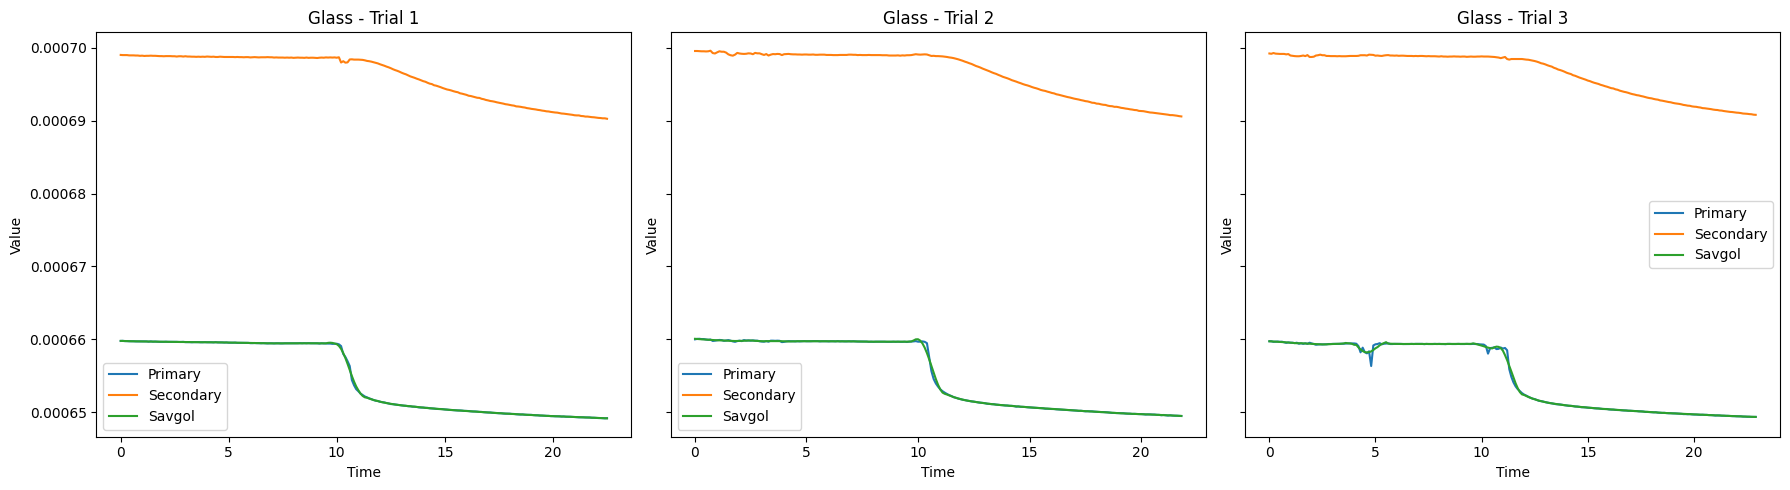

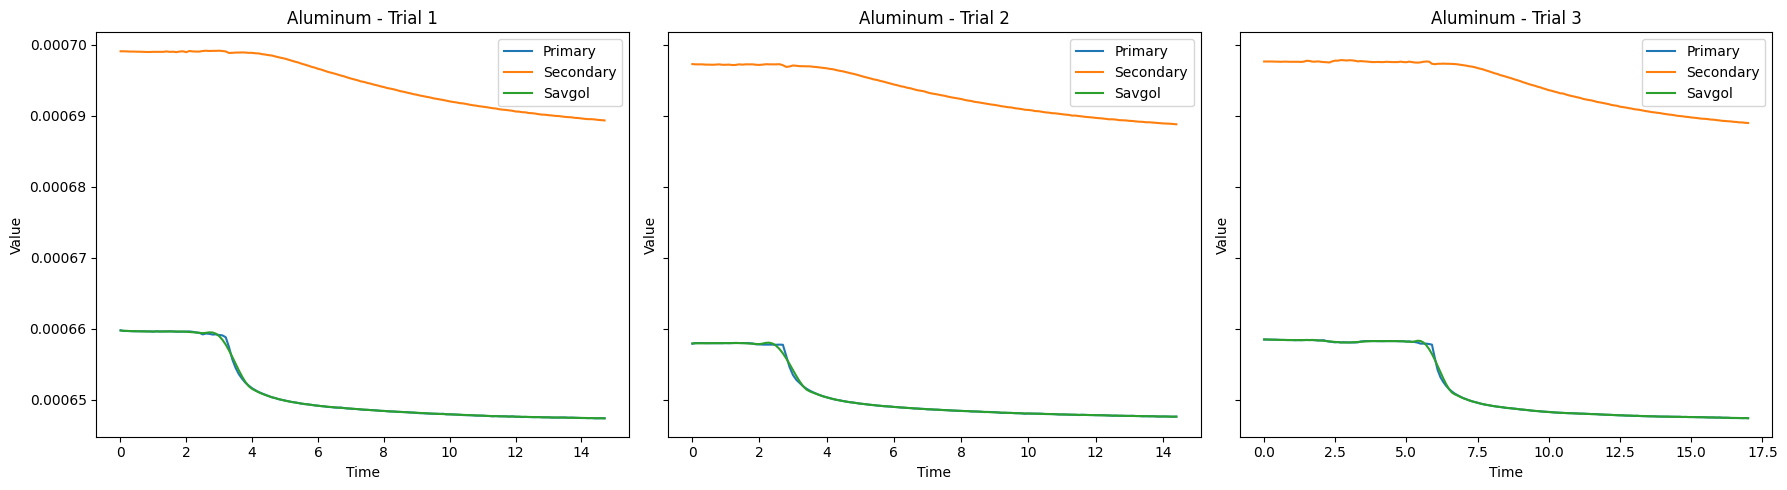

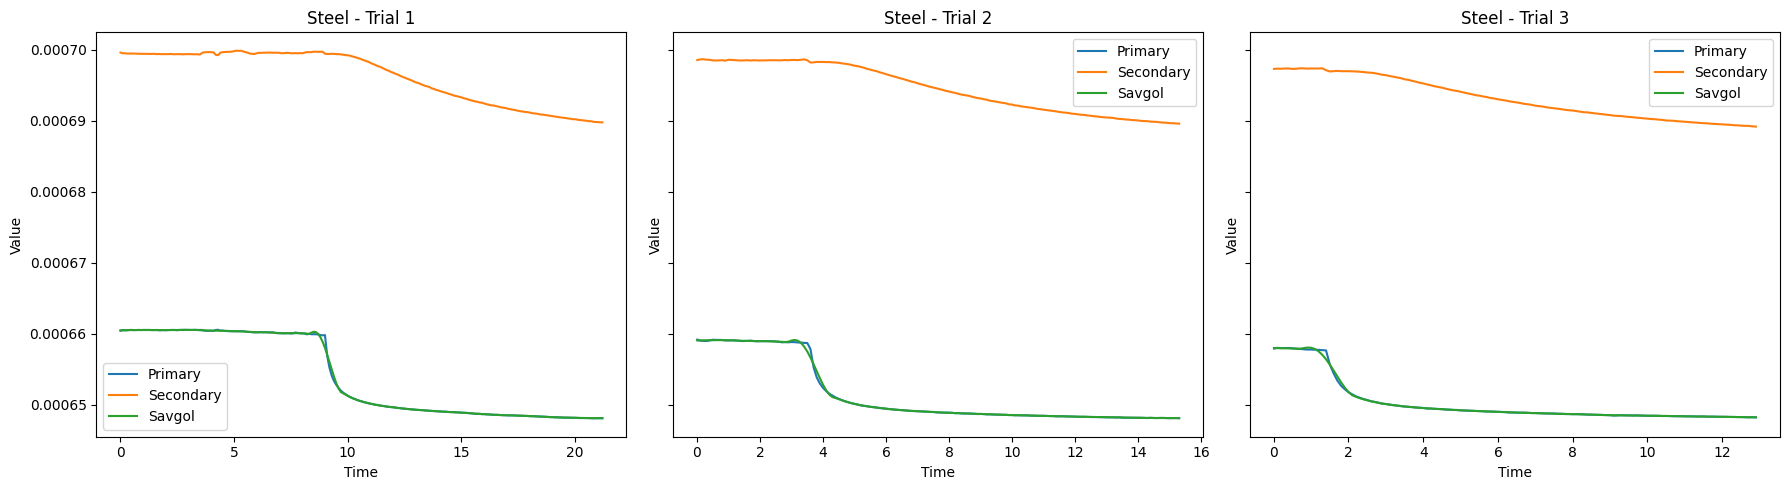

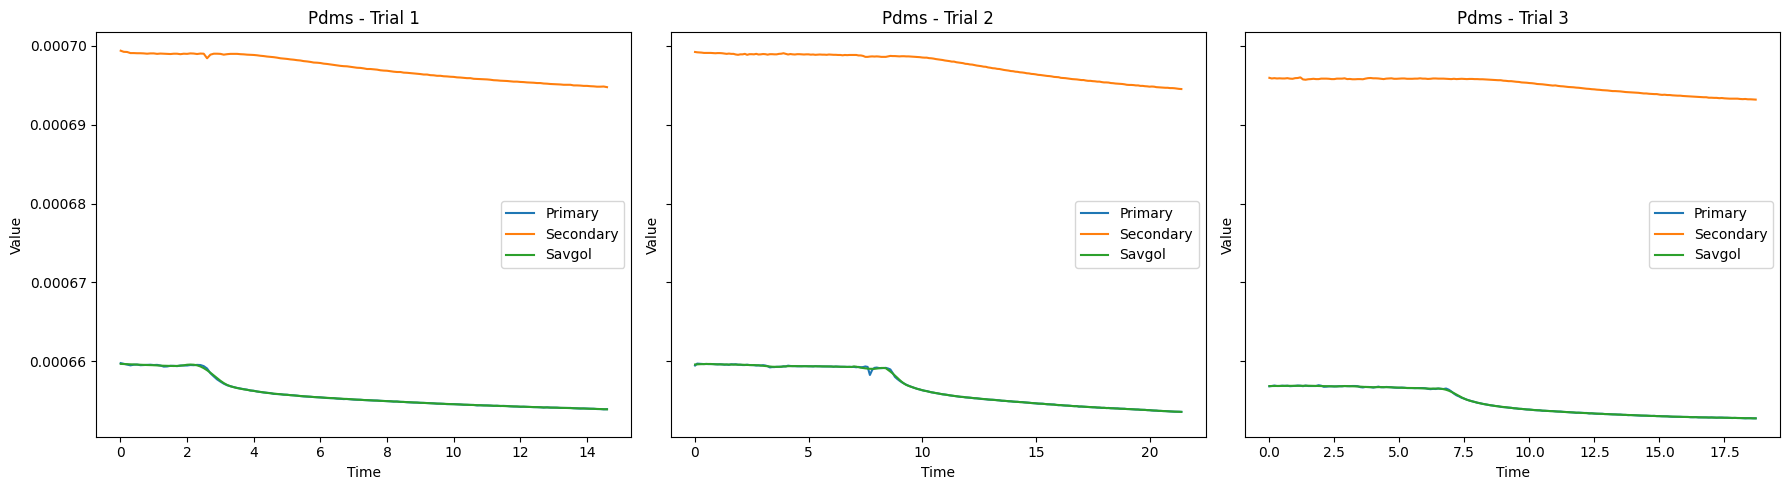

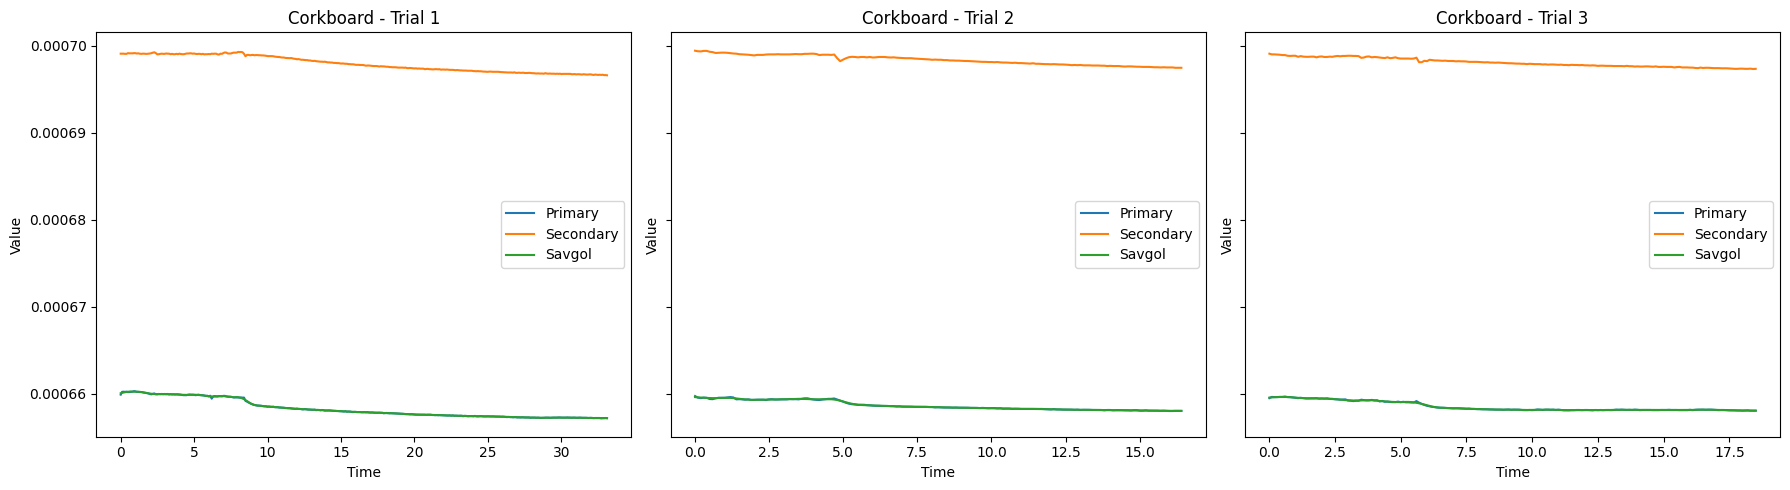

In [150]:
#TEST

#y_smooth = pd.DataFrame()

for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        
        y_new = subset['Primary'].to_numpy()
        y_smooth = savgol_filter(y_new, 15, 2)

        subset['Smooth'] = y_smooth

        ax.plot(subset['Time'].values, subset['Smooth'], label='Savgol')

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()


#y_smooth
#y_new
#subset['Smooth']

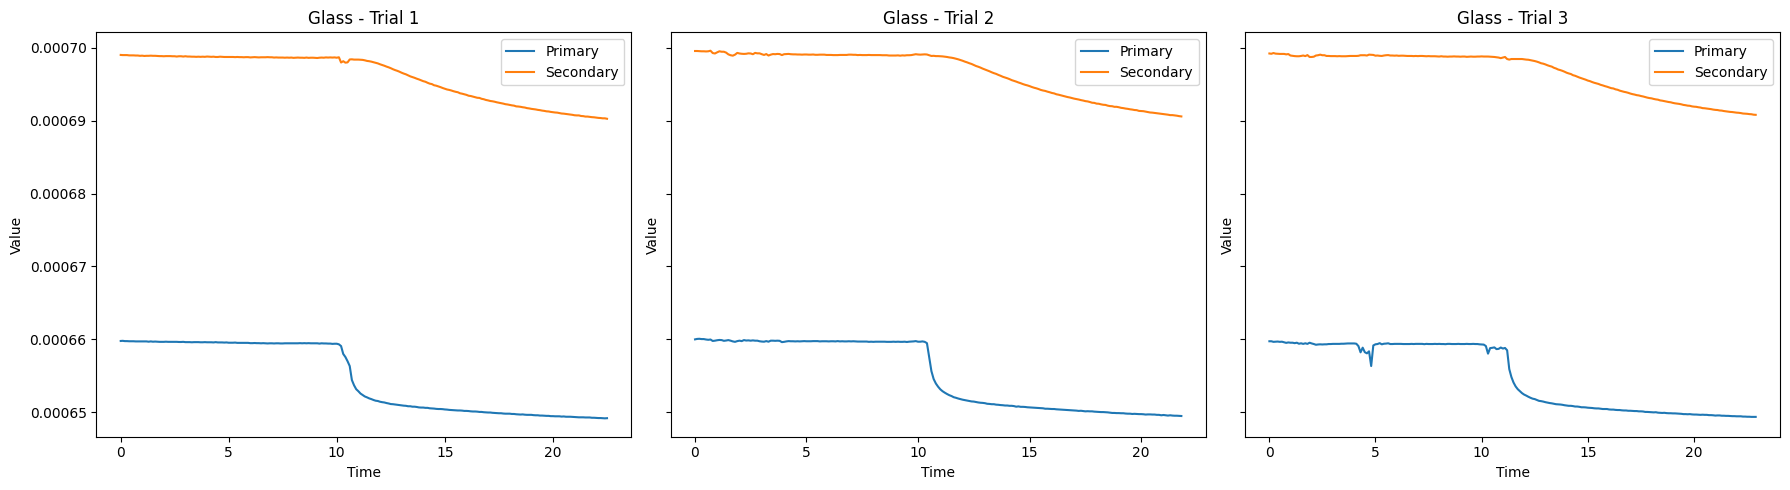

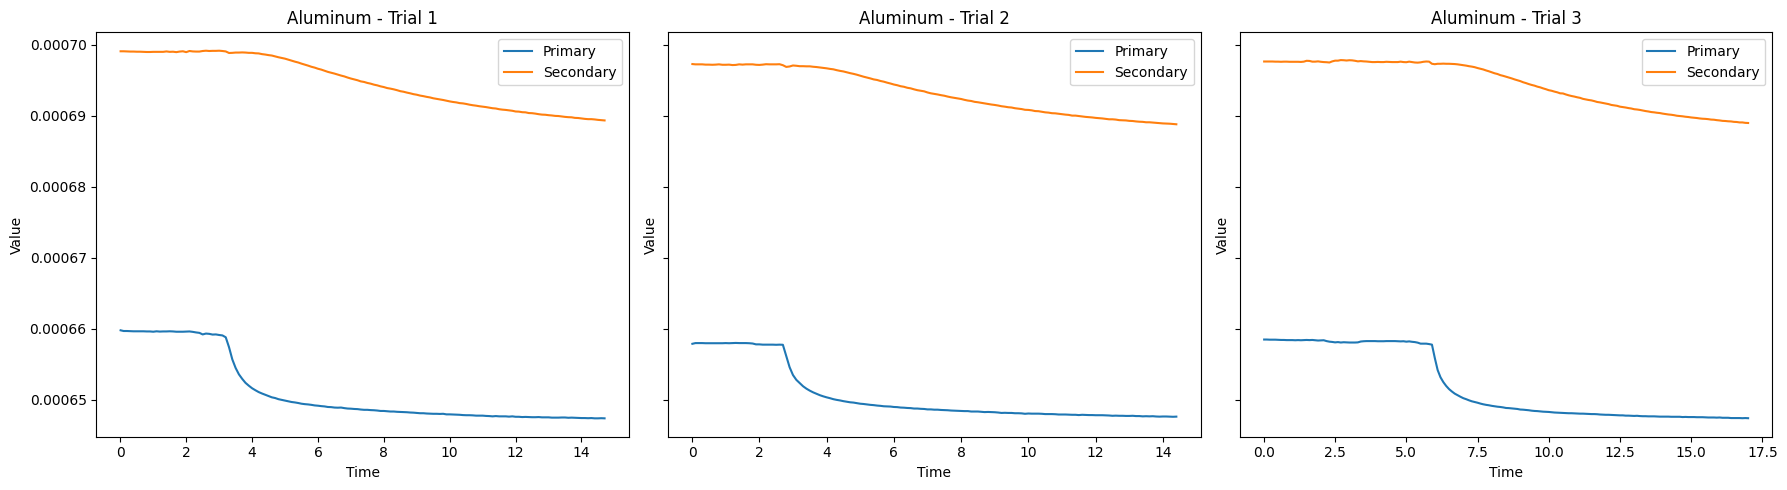

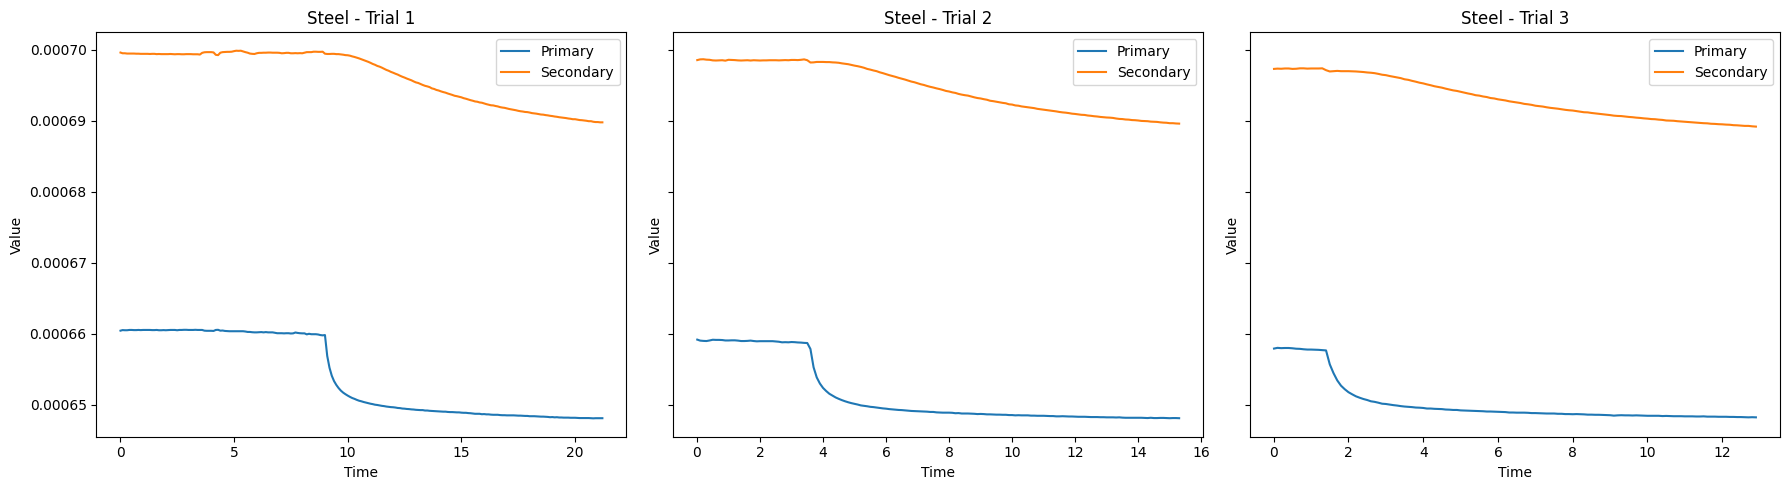

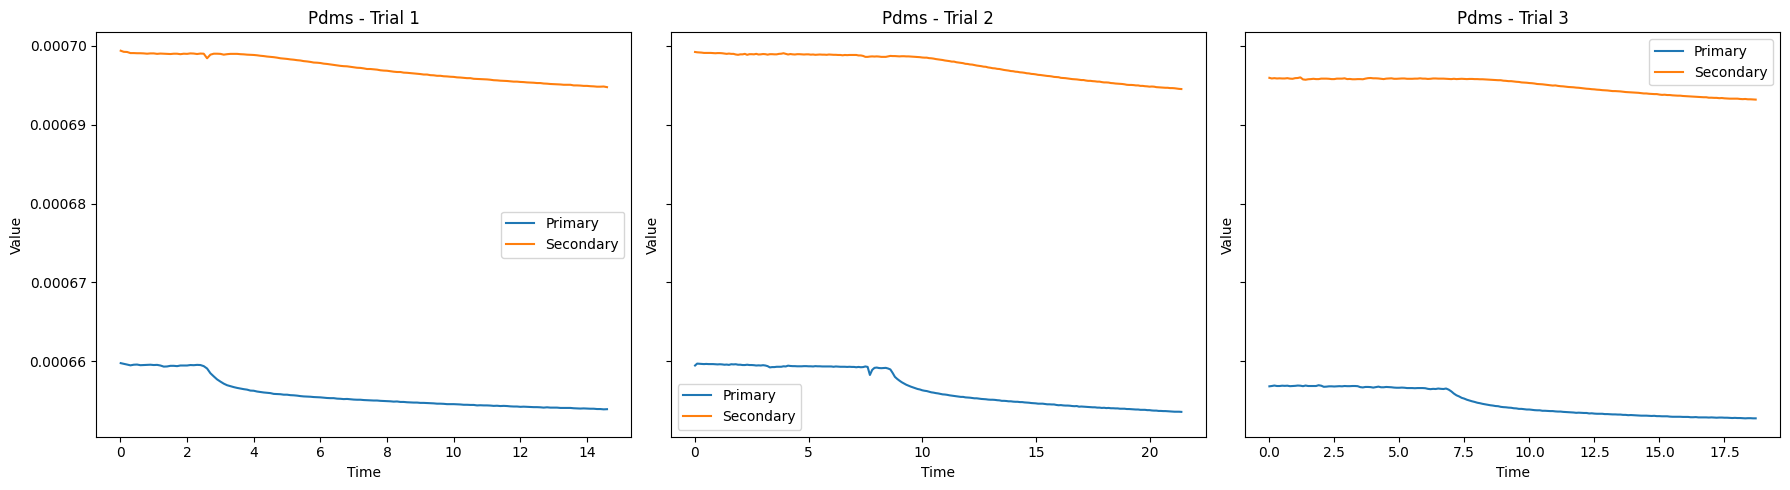

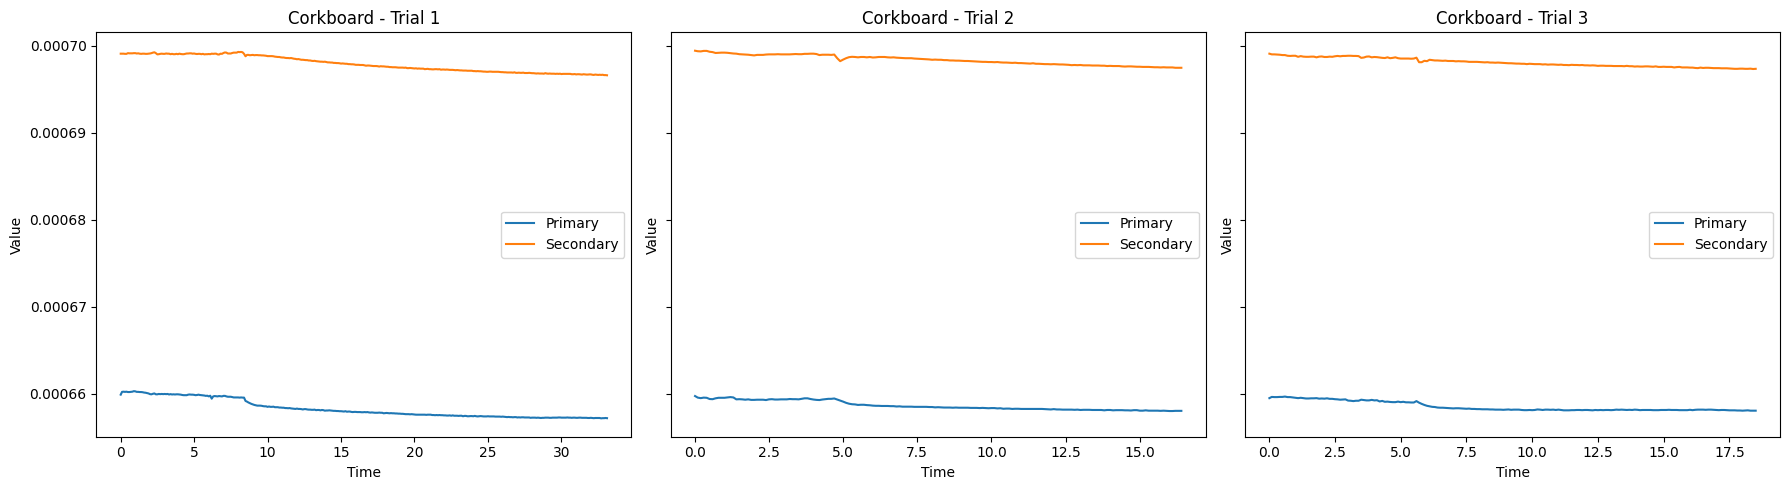

In [119]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

## Plot Primary-Secondary Differnce

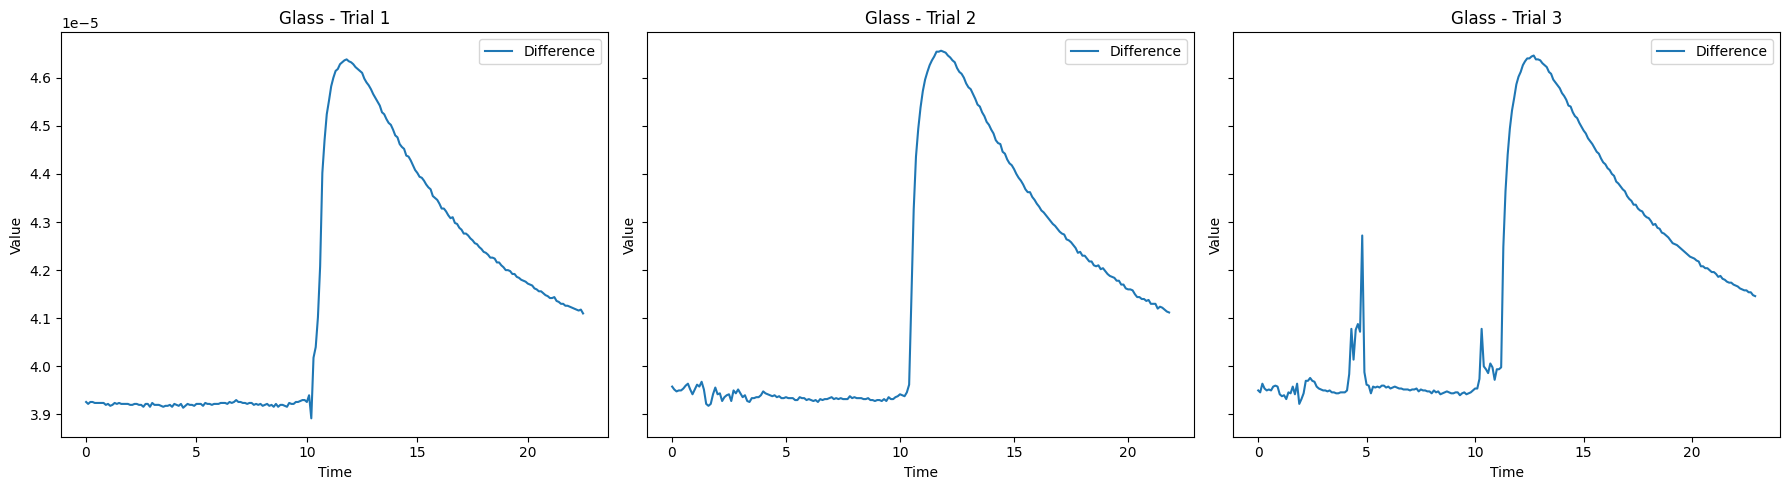

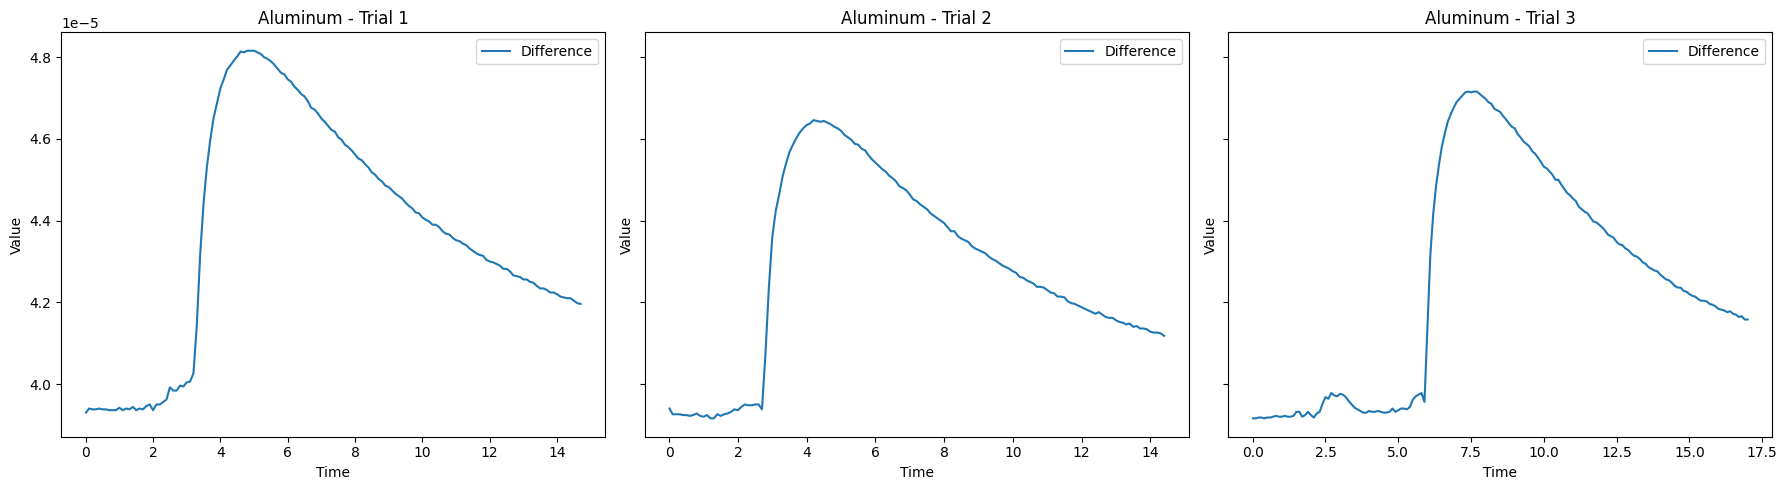

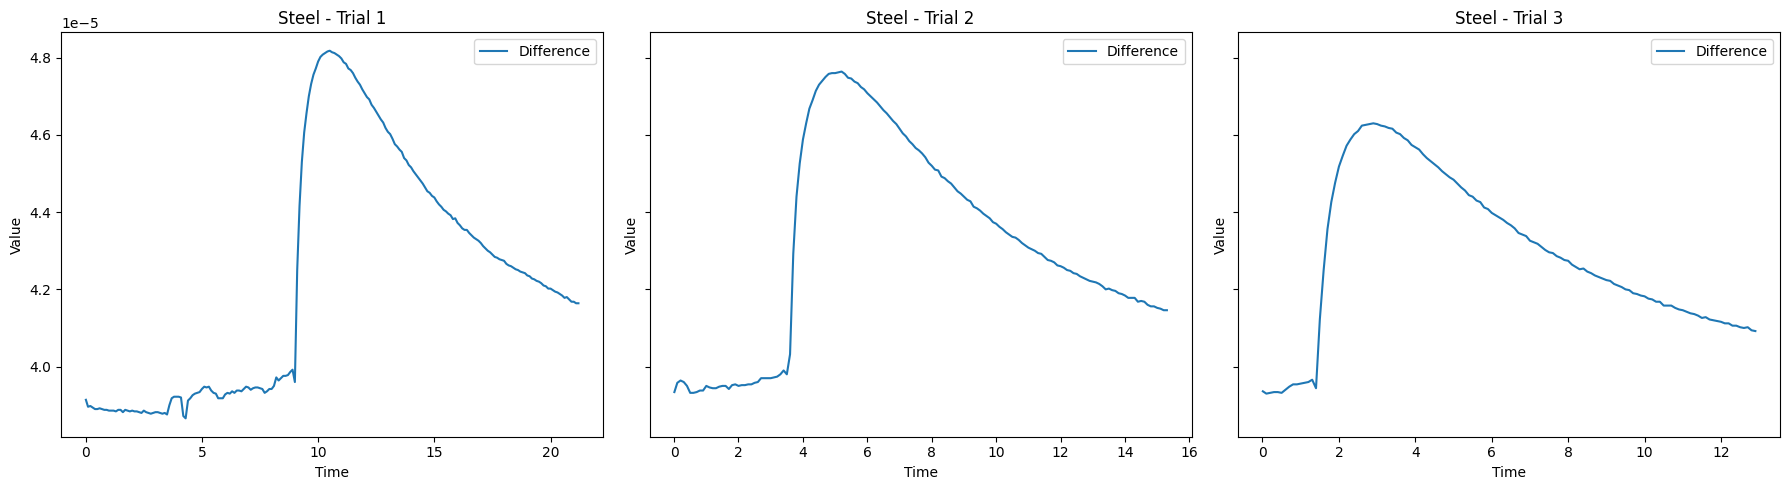

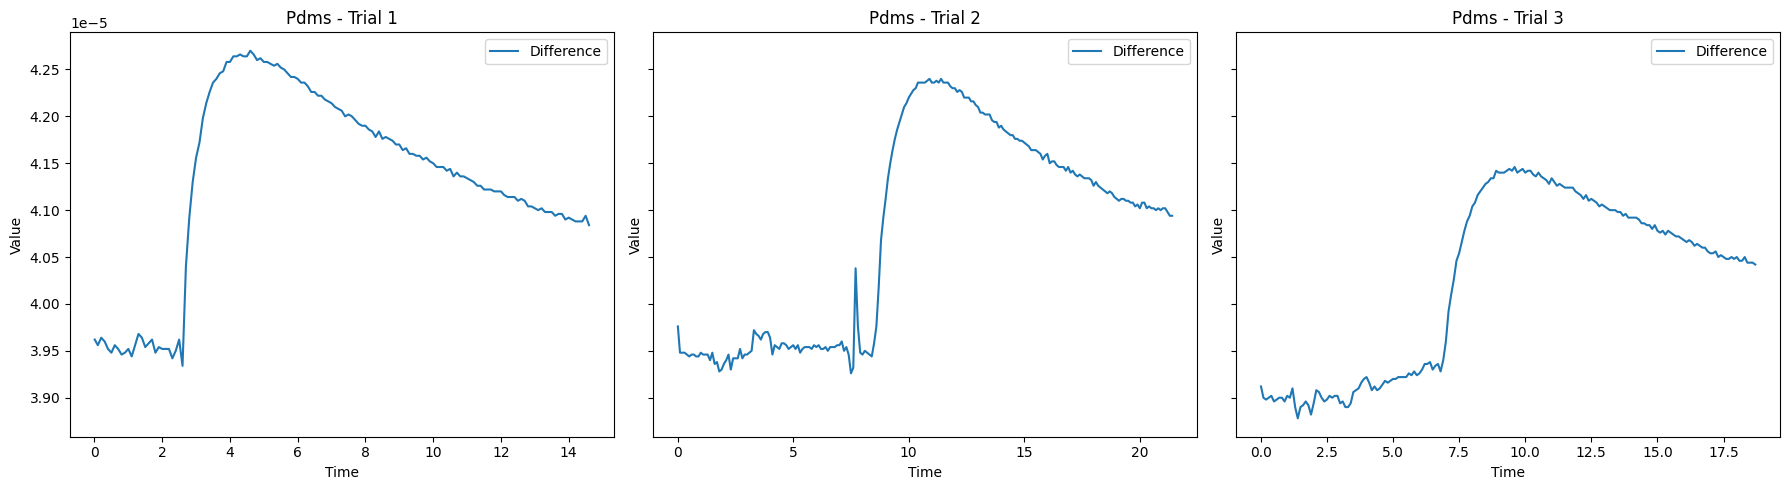

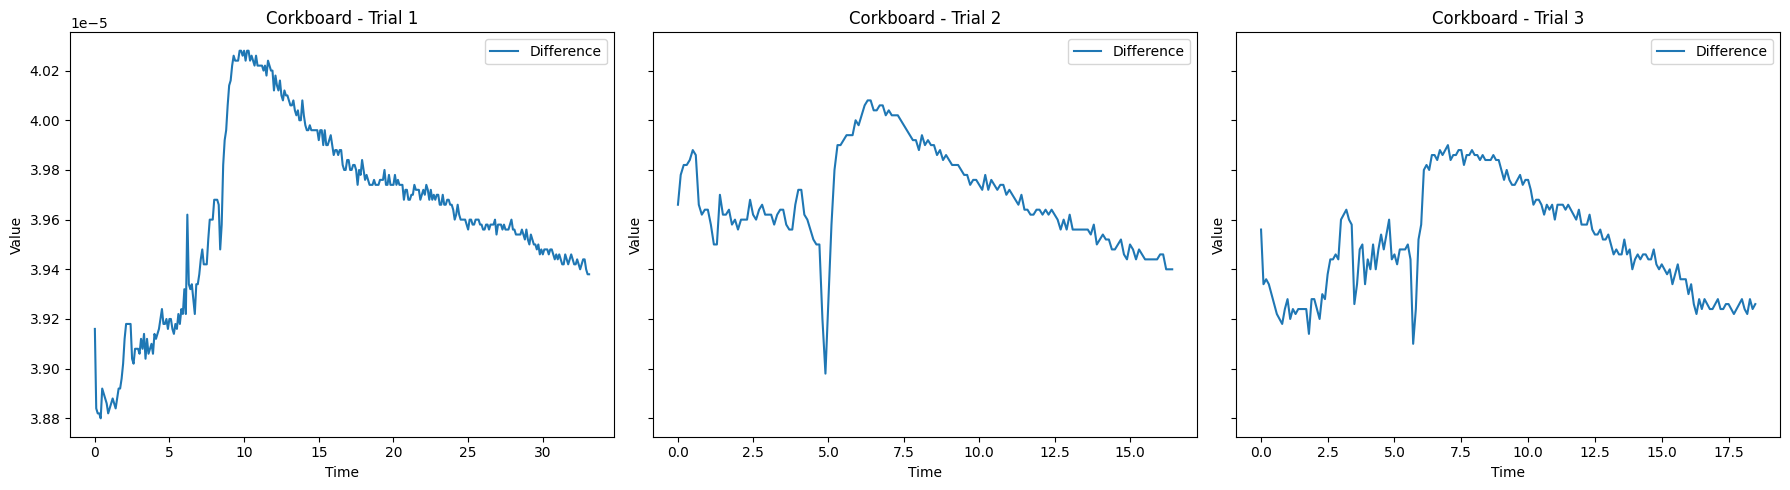

In [75]:
data['diff'] = data['Secondary'] - data['Primary']
data['abs_diff'] = data['diff'].abs()

# Plotting Primary and Secondary Readings Over Time
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['diff'], label='Difference')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Elbow Finder

In [ ]:
#Ask if this makes any differences

def find_global_first_elbow(subset):
    time_col="Time"
    signal_col="Primary"
    smooth_window=15
    polyorder=2
    pre_search_window=30
    threshold_frac=0.15
    direction="drop"

In [118]:
time_col="Time"
signal_col="Primary"
smooth_window=15

df = subset.sort_values(time_col)

t = df[time_col].to_numpy(dtype=float)
y = df[signal_col].to_numpy(dtype=float)

mask = np.isfinite(t) & np.isfinite(y)
t = t[mask]
y = y[mask]

n = len(y)

smooth_window = min(smooth_window, n - 1 if n % 2 == 0 else n)
smooth_window


15

In [128]:
def find_global_first_elbow(
    subset,
    time_col="Time",
    signal_col="Primary",
    smooth_window=15,
    polyorder=2,
    pre_search_window=30,
    threshold_frac=0.15,
    direction="drop"
):
    """
    Finds elbow by first locating the strongest global slope change,
    then searching backward to find the clean start of the elbow.
    """

    df = subset.sort_values(time_col)

    t = df[time_col].to_numpy(dtype=float)
    y = df[signal_col].to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    n = len(y)

    if n < 10:
        return np.nan, np.nan, None

    # Make SavGol window valid
    smooth_window = min(smooth_window,n)

    if smooth_window % 2 == 0:
        smooth_window -= 1

    if smooth_window <= polyorder:
        smooth_window = polyorder + 3
        if smooth_window % 2 == 0:
            smooth_window += 1

    # Smooth signal
    y_smooth = savgol_filter(y, window_length=smooth_window, polyorder=polyorder)

    # Derivative
    dy = np.gradient(y_smooth, t)

    # Find strongest global slope
    if direction == "drop":
        peak_idx = np.argmin(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope  # negative value
        active = dy < threshold

    elif direction == "rise":
        peak_idx = np.argmax(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope
        active = dy > threshold

    else:
        raise ValueError("direction must be 'drop' or 'rise'")

    # Search backward from strongest slope to find start of elbow
    start_idx = peak_idx

    for j in range(peak_idx, 0, -1):
        if not active[j]:
            start_idx = j + 1
            break

    # Optional refinement: search only near the strongest slope region
    start_idx = max(0, start_idx)

    return t[start_idx], y[start_idx], start_idx

glass - Trial 0 - 101
glass - Trial 1 - 101
glass - Trial 2 - 109


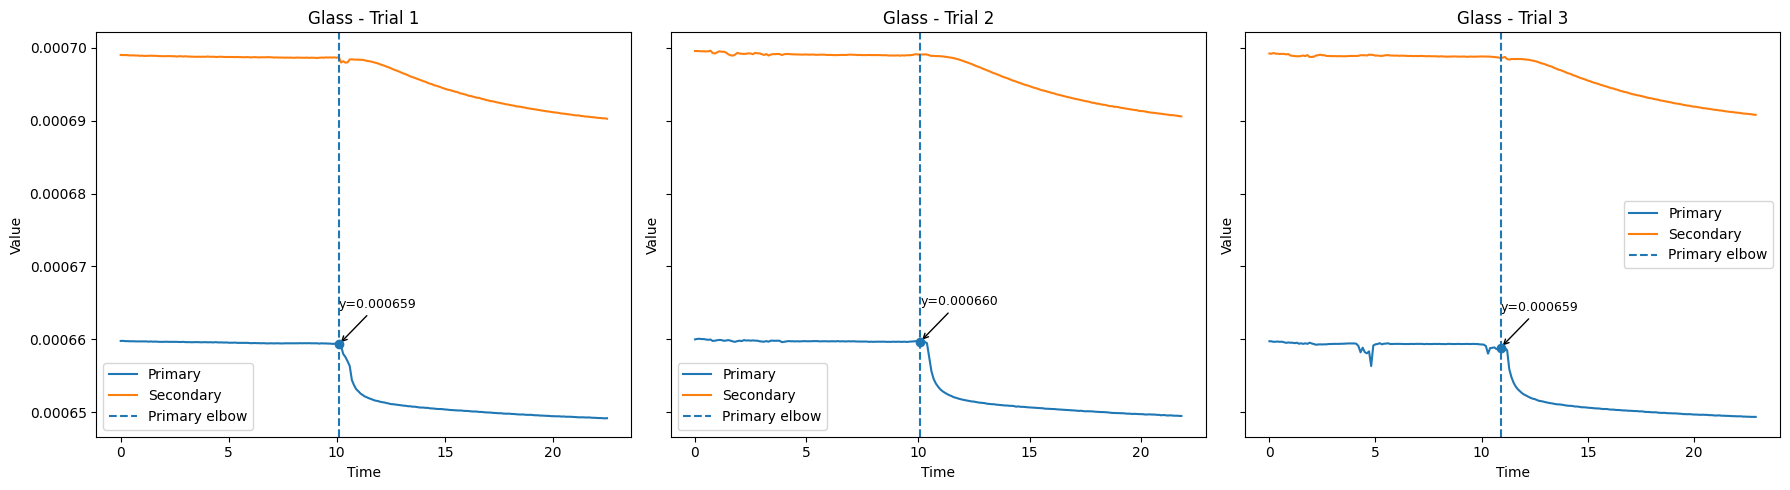

aluminum - Trial 0 - 30
aluminum - Trial 1 - 25
aluminum - Trial 2 - 56


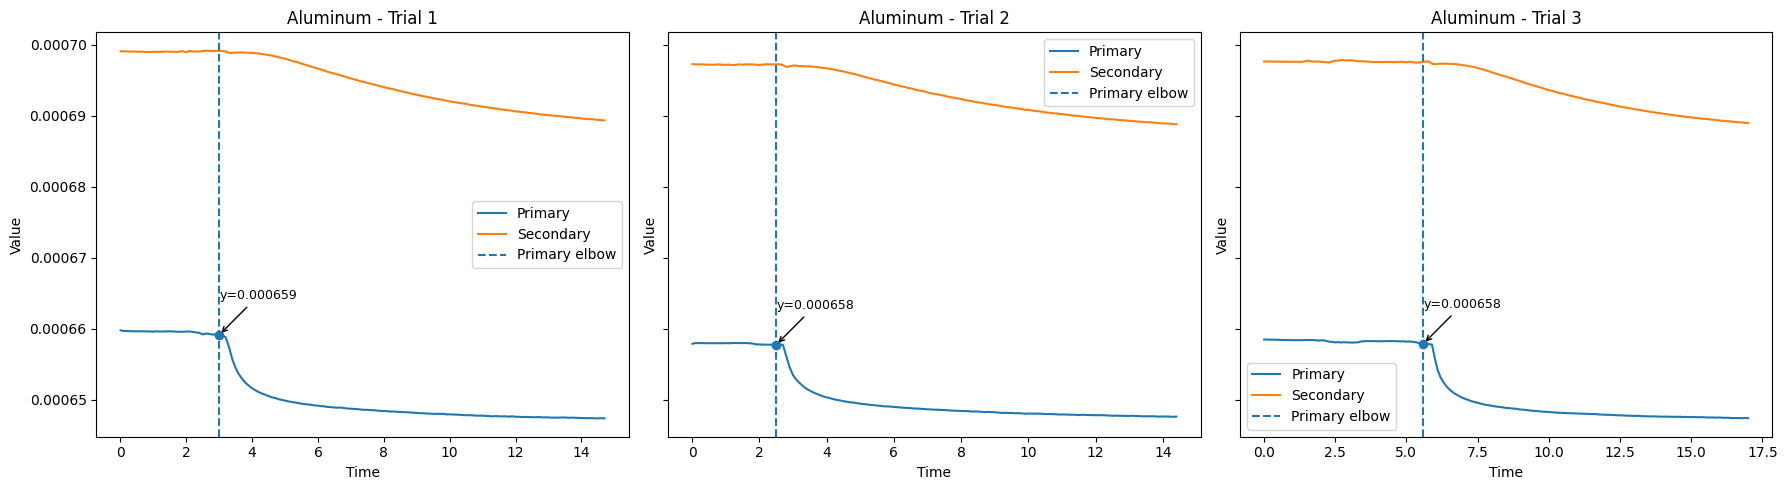

steel - Trial 0 - 87
steel - Trial 1 - 33
steel - Trial 2 - 12


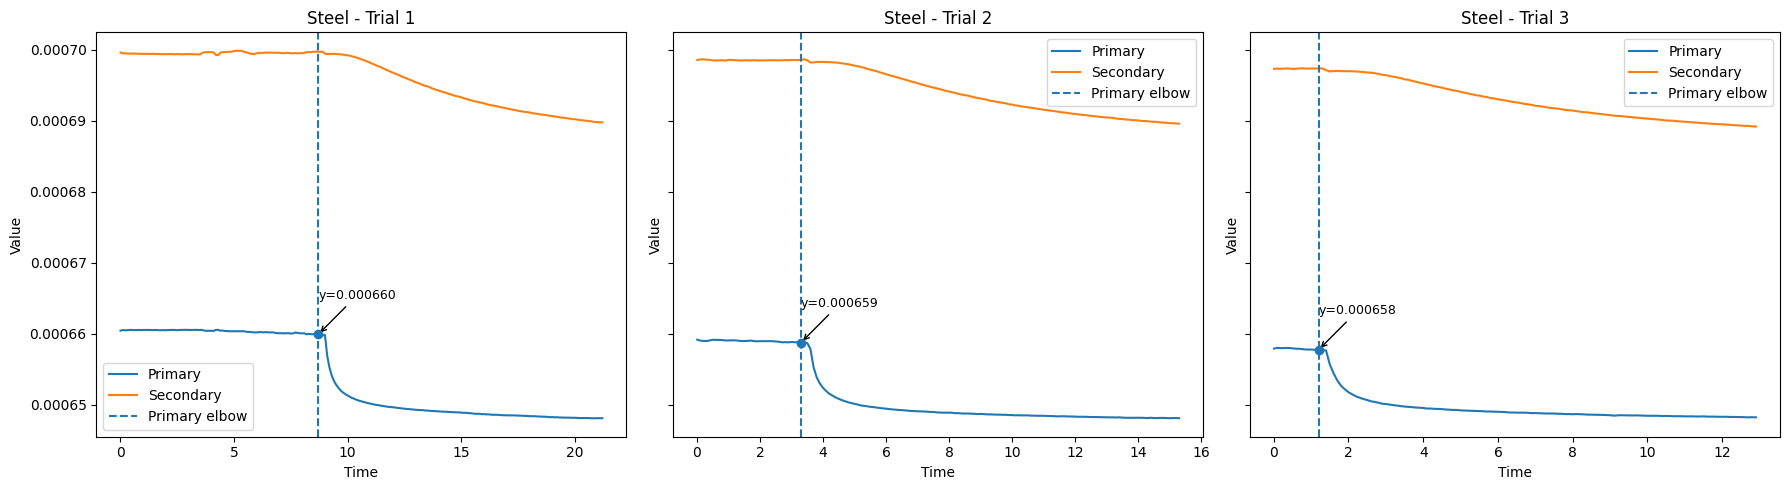

pdms - Trial 0 - 23
pdms - Trial 1 - 84
pdms - Trial 2 - 67


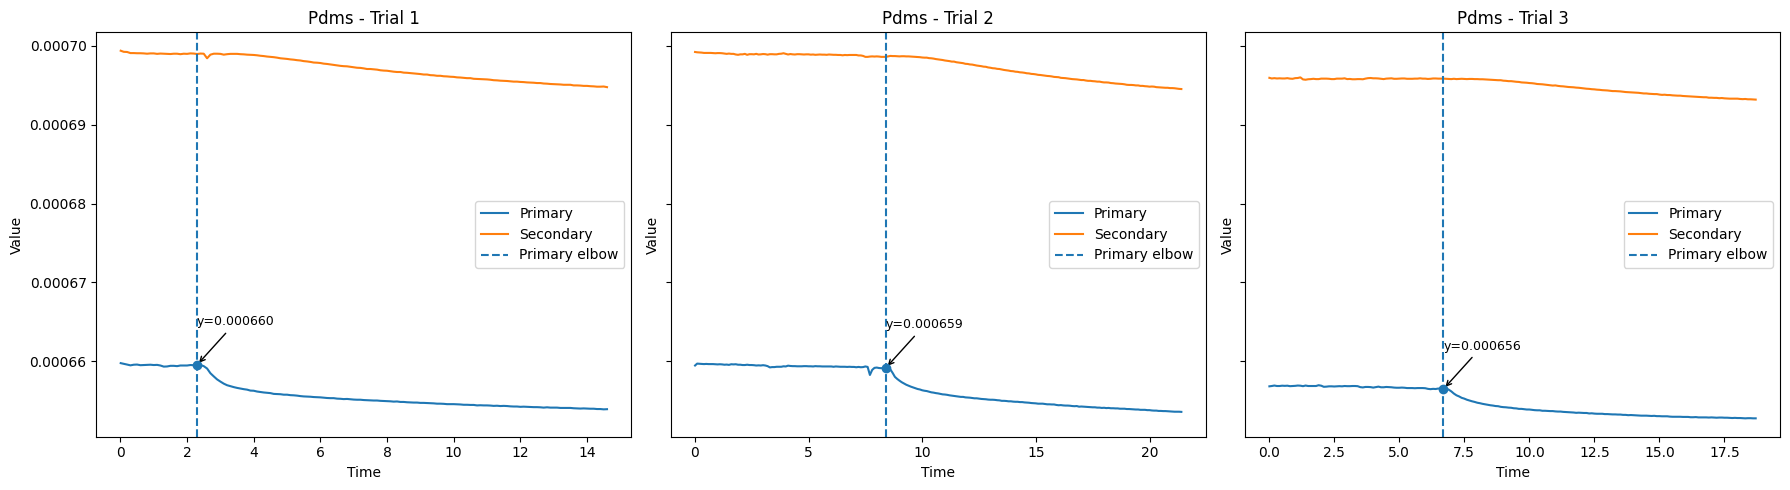

corkboard - Trial 0 - 81
corkboard - Trial 1 - 47
corkboard - Trial 2 - 54


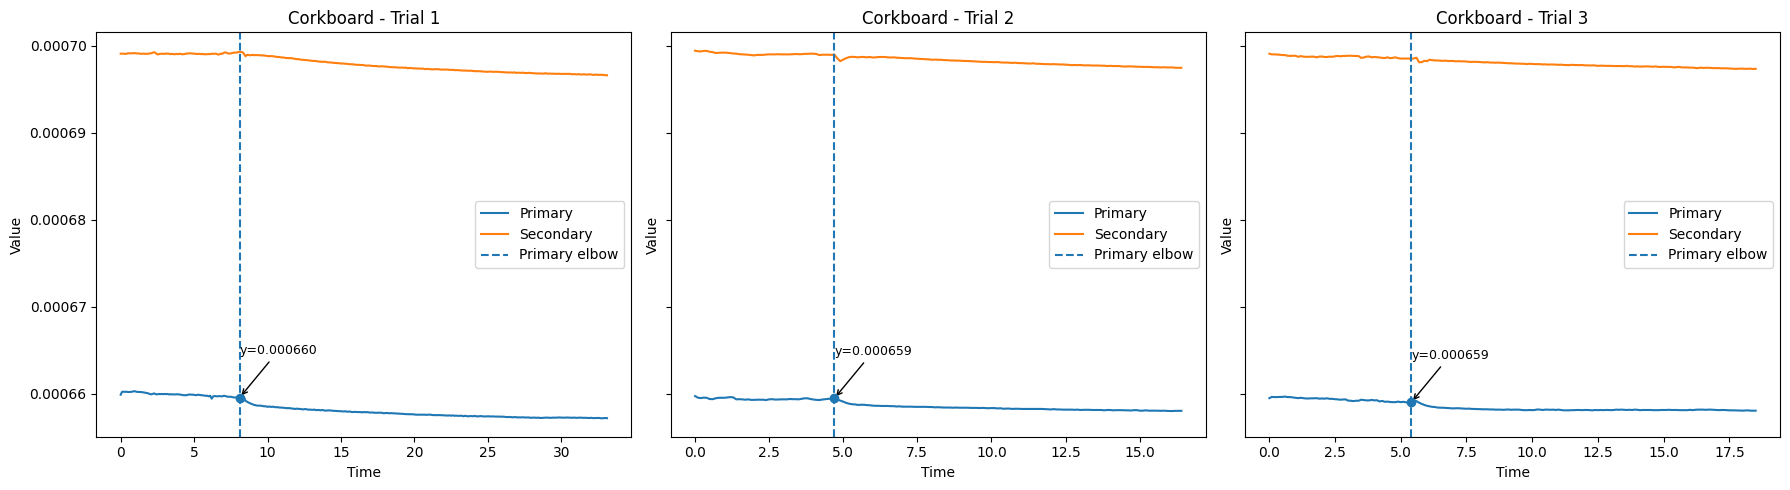

In [129]:
elbow_loc = {}
for m in materials:
    elbow_trials = {}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)].copy()
        subset = subset.sort_values('Time')

        elbow_time, elbow_value, elbow_idx = find_global_first_elbow(
            subset,
            time_col="Time",
            signal_col="Primary",
            smooth_window=15,
            polyorder=2,
            threshold_frac=0.3,
            direction="drop"
        )
        elbow_trials[i+1] = elbow_idx

        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()
    elbow_loc[m] = elbow_trials
    

    plt.tight_layout()
    plt.show()

glass - Trial 1 - 102
glass - Trial 2 - 105
glass - Trial 3 - 113


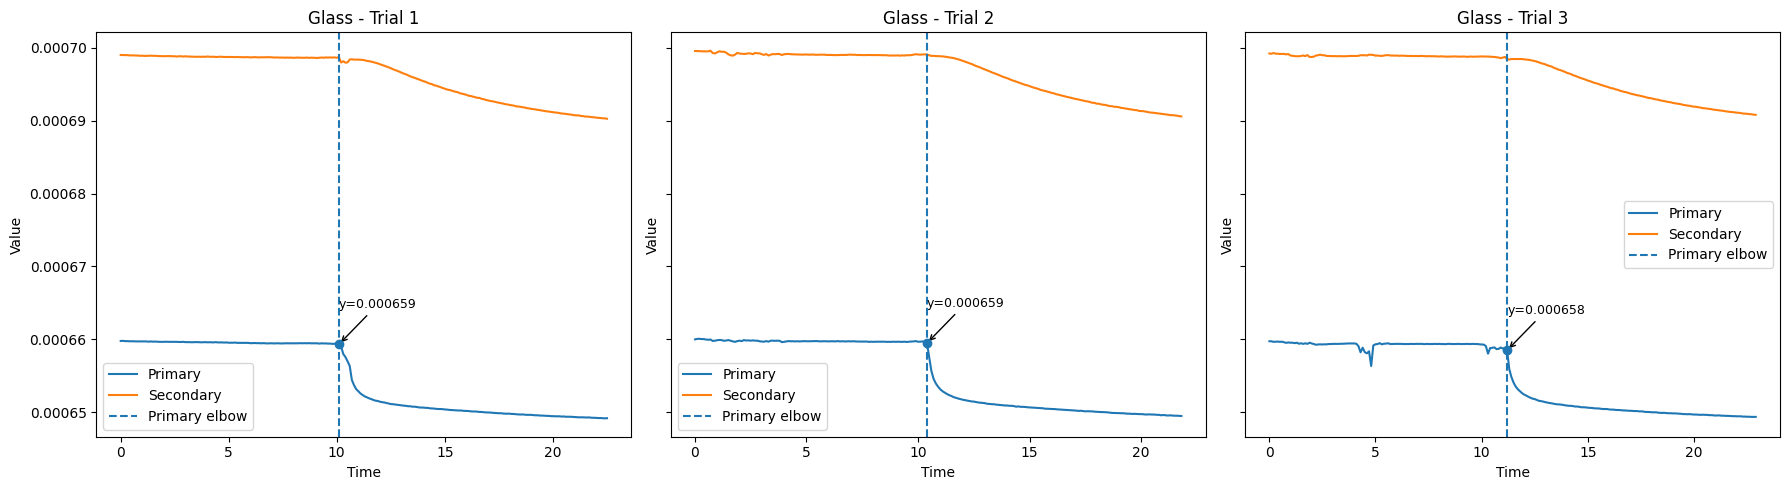

aluminum - Trial 1 - 33
aluminum - Trial 2 - 28
aluminum - Trial 3 - 60


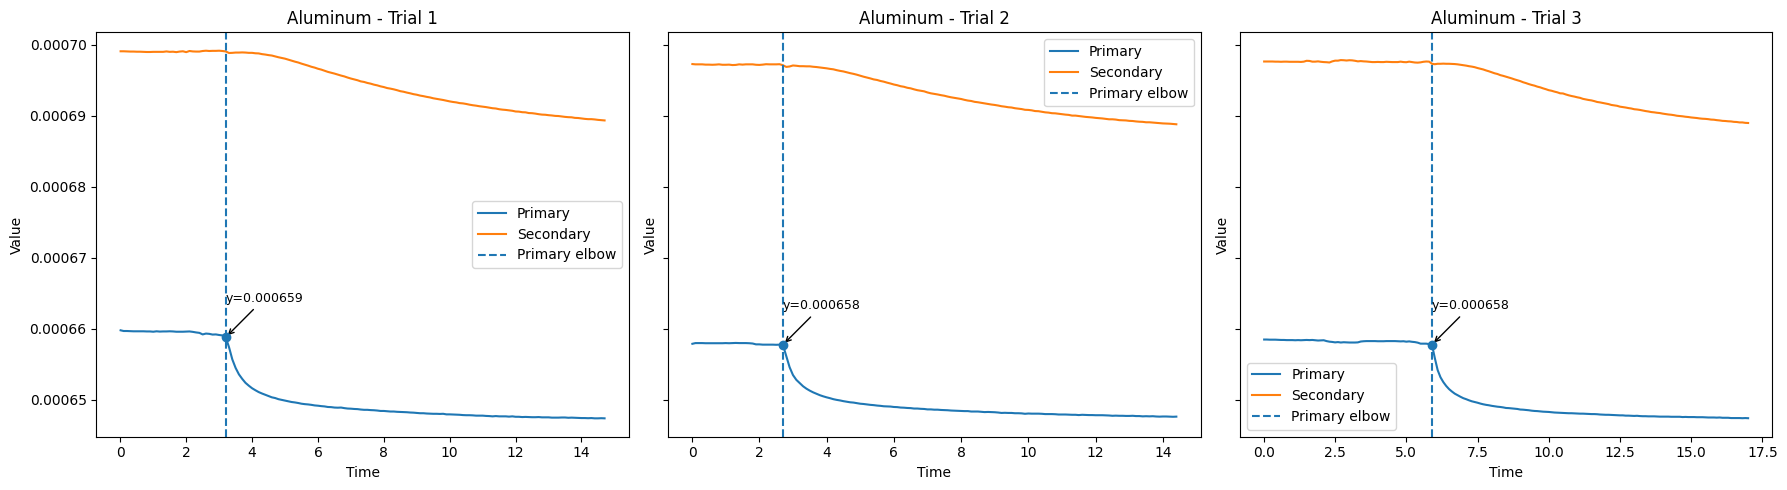

steel - Trial 1 - 91
steel - Trial 2 - 37
steel - Trial 3 - 15


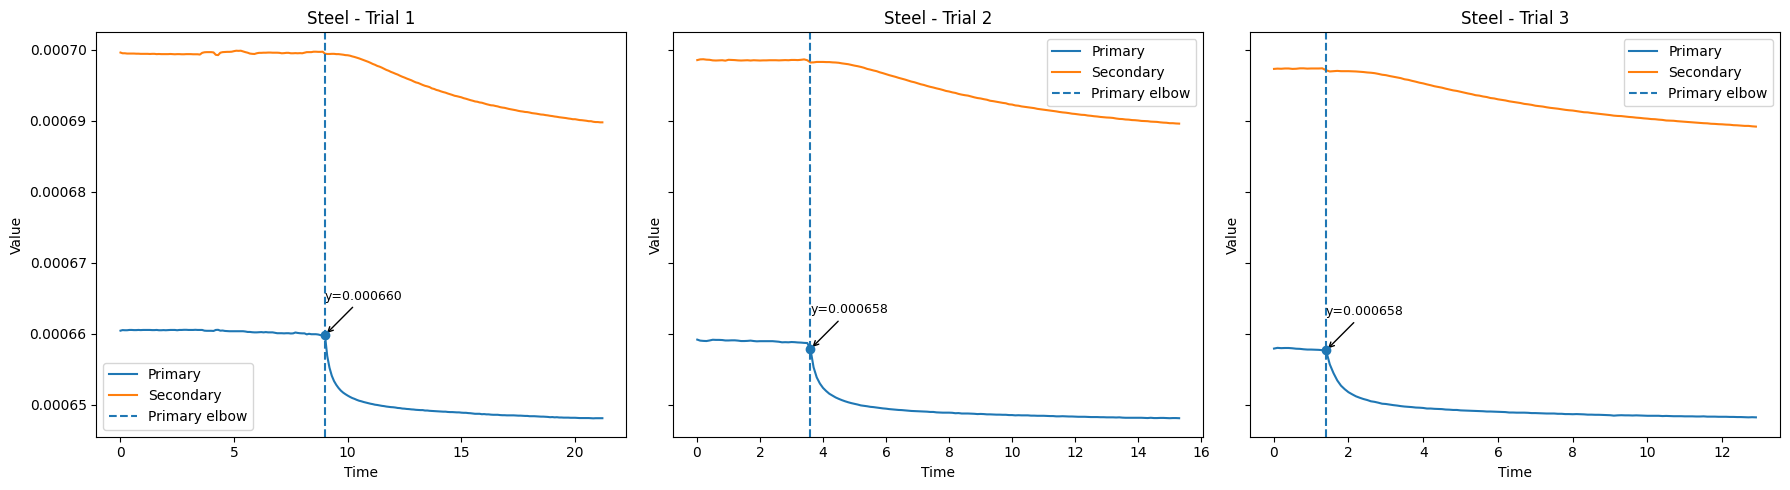

pdms - Trial 1 - 26
pdms - Trial 2 - 85
pdms - Trial 3 - 70


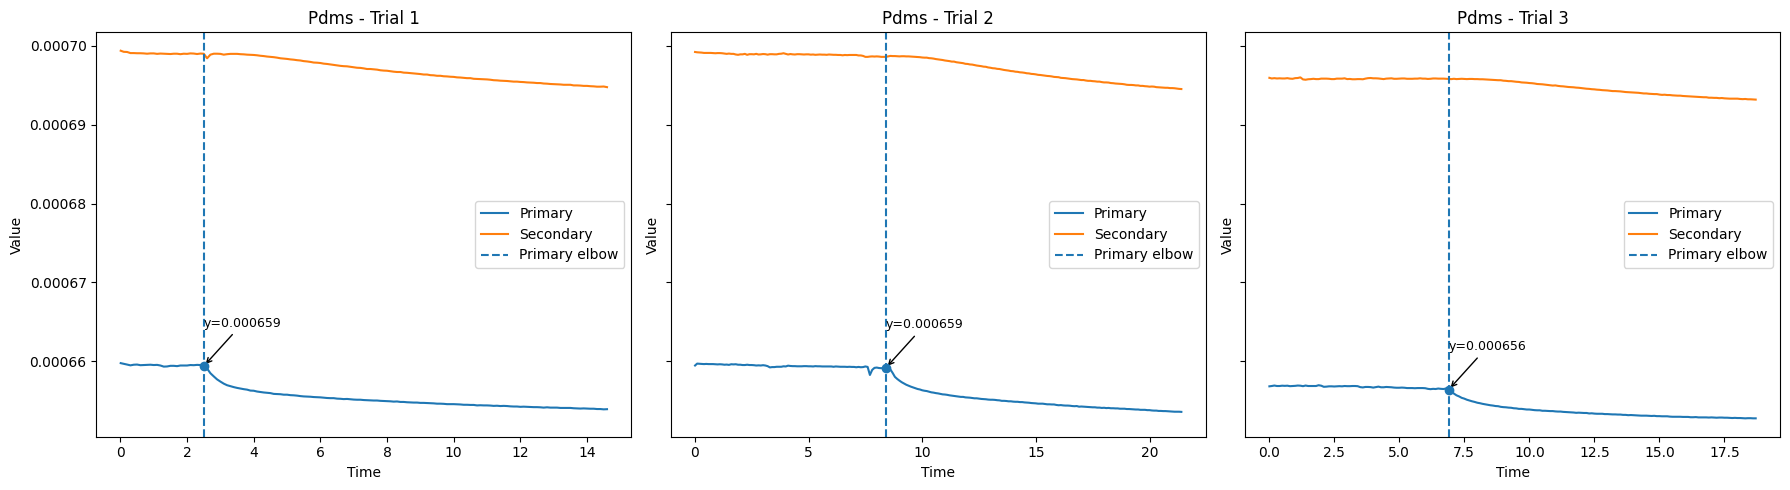

corkboard - Trial 1 - 84
corkboard - Trial 2 - 48
corkboard - Trial 3 - 57


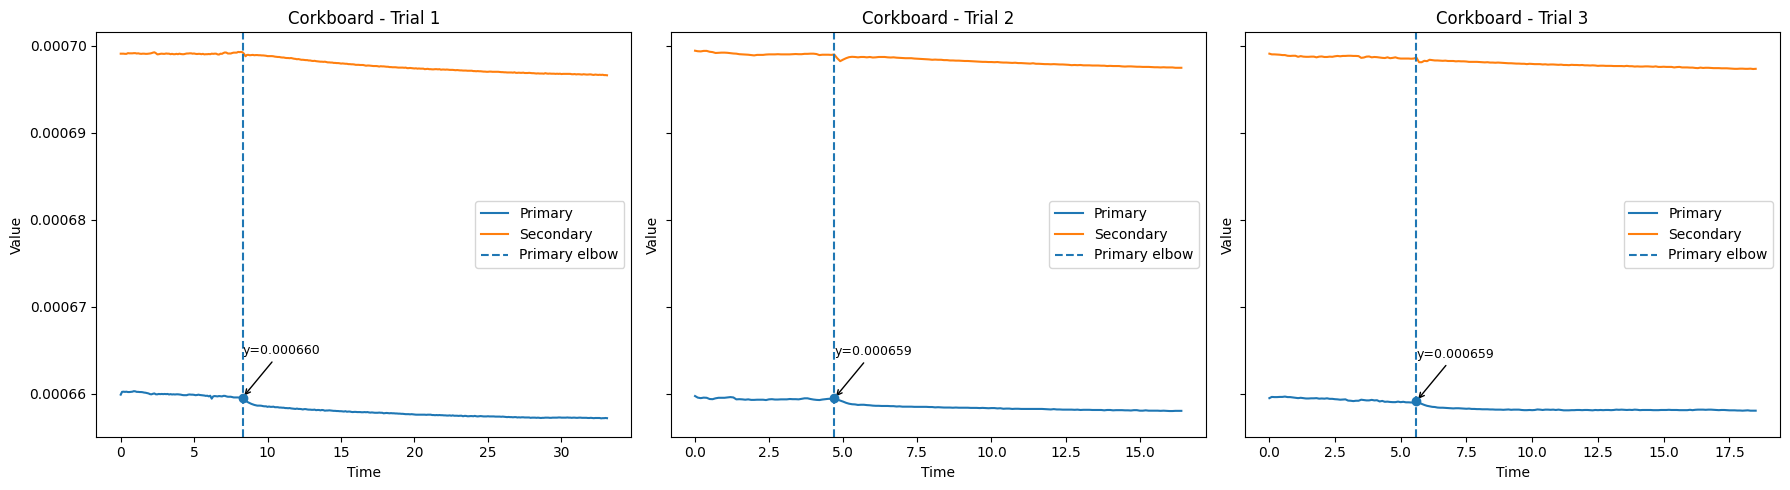

In [56]:
elbow_loc['glass'][1] = 102
elbow_loc['glass'][2] = 105
elbow_loc['glass'][3] = 113

elbow_loc['aluminum'][1] = 33
elbow_loc['aluminum'][2] = 28
elbow_loc['aluminum'][3] = 60

elbow_loc['steel'][1] = 91
elbow_loc['steel'][2] = 37
elbow_loc['steel'][3] = 15

elbow_loc['pdms'][1] = 26
elbow_loc['pdms'][2] = 85
elbow_loc['pdms'][3] = 70


elbow_loc['corkboard'][1] = 84
elbow_loc['corkboard'][2] = 48
elbow_loc['corkboard'][3] = 57

for m, elbows in elbow_loc.items():

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for plot_idx, (i, elbow_idx) in enumerate(elbows.items()):
        ax = axes[plot_idx]

        subset = data[(data['Sample'] == m) & (data['Trial'] == i)].copy()
        subset = subset.sort_values('Time')

        elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
        elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [57]:
data["is_elbow"] = False
data["filter"] = False

for (sample, trial), subset in data.groupby(["Sample", "Trial"]):

    elbow_idx = elbow_loc[sample][trial]-10
    elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
    elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

    print(f"{sample} - Trial {trial} - {elbow_idx}")

    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'filter'] = True
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_time'] = elbow_time
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_idx'] = elbow_idx

    if not np.isnan(elbow_time):
        # find the actual row in the original dataframe closest to the elbow time
        elbow_row_idx = subset["Time"].sub(elbow_time).abs().idxmin()

        data.loc[elbow_row_idx, "is_elbow"] = True
        data.loc[elbow_row_idx, "elbow_time"] = elbow_time
        data.loc[elbow_row_idx, "elbow_value"] = elbow_value

data = data[data['filter']]
data['Time'] = data['Time'] - data['elbow_time']
data['index'] = data['index'] - data['elbow_idx']
data = data[data['index'] < 100]

aluminum - Trial 1.0 - 23
aluminum - Trial 2.0 - 18
aluminum - Trial 3.0 - 50
corkboard - Trial 1.0 - 74
corkboard - Trial 2.0 - 38
corkboard - Trial 3.0 - 47
glass - Trial 1.0 - 92
glass - Trial 2.0 - 95
glass - Trial 3.0 - 103
pdms - Trial 1.0 - 16
pdms - Trial 2.0 - 75
pdms - Trial 3.0 - 60
steel - Trial 1.0 - 81
steel - Trial 2.0 - 27
steel - Trial 3.0 - 5


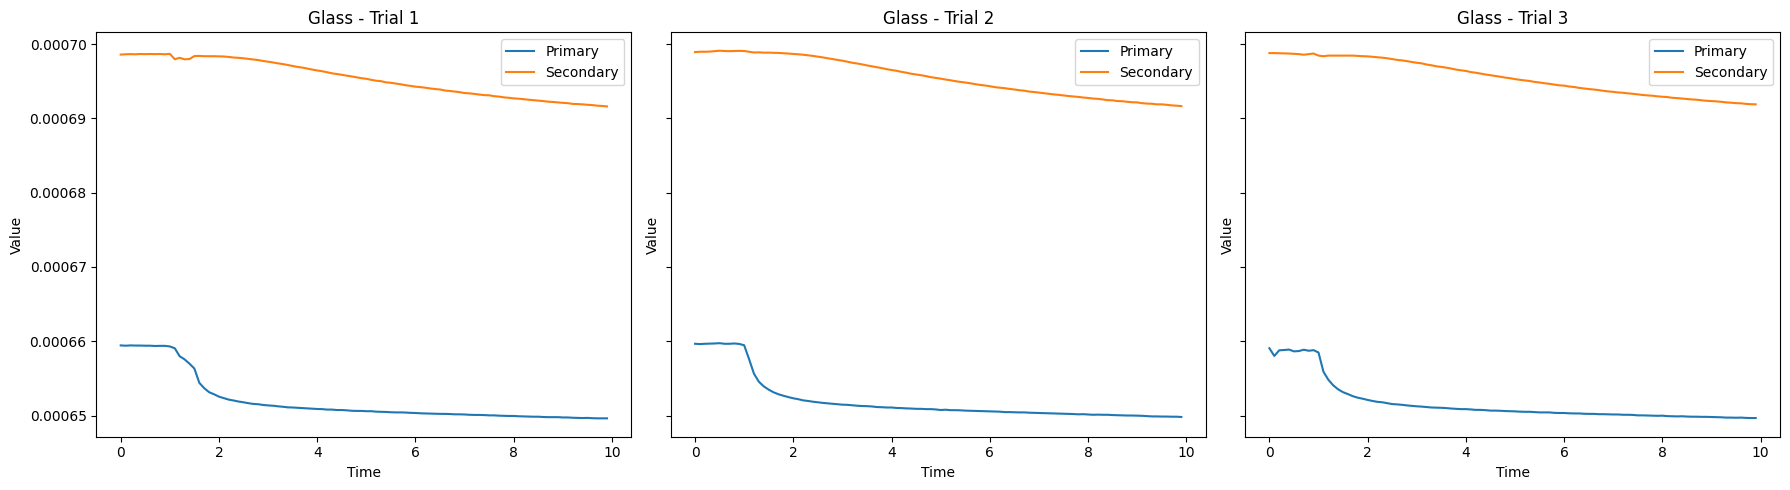

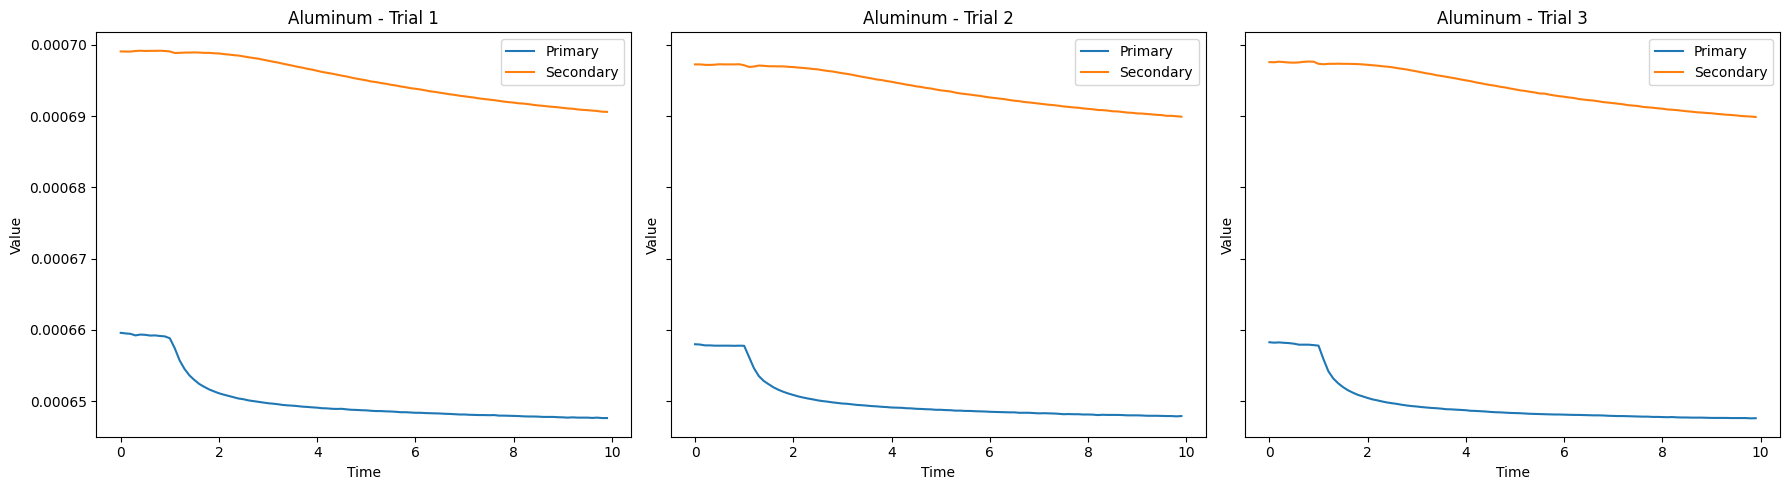

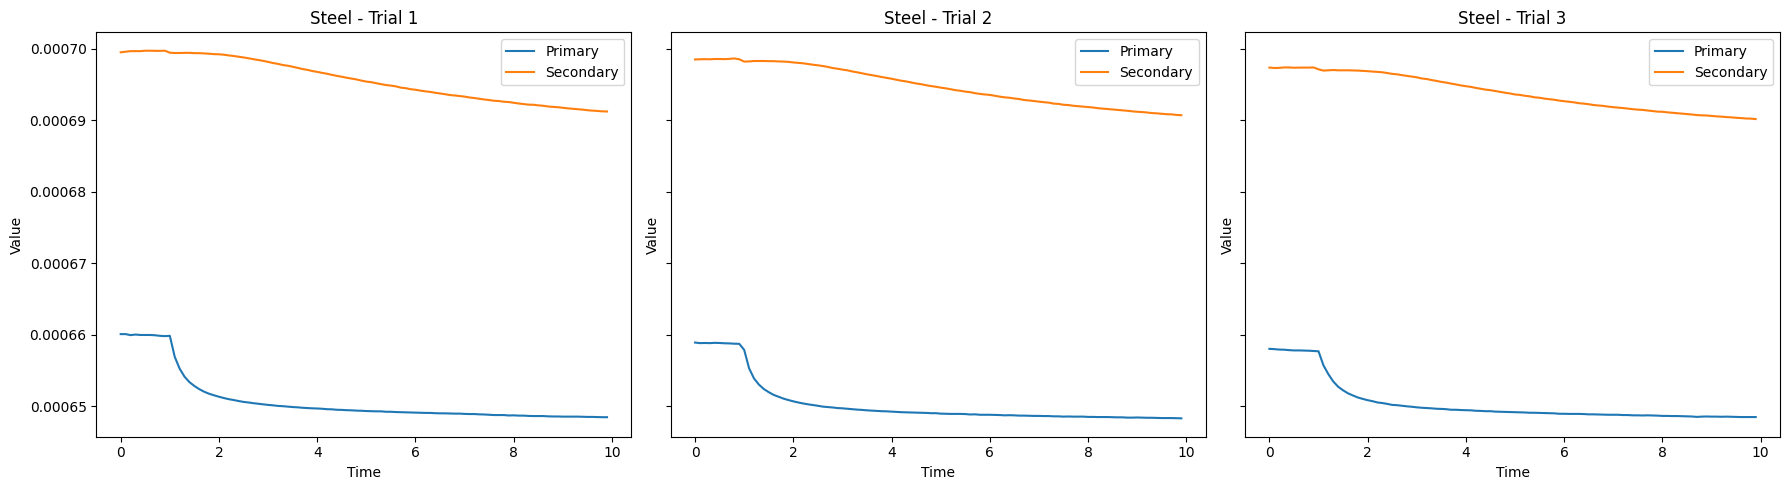

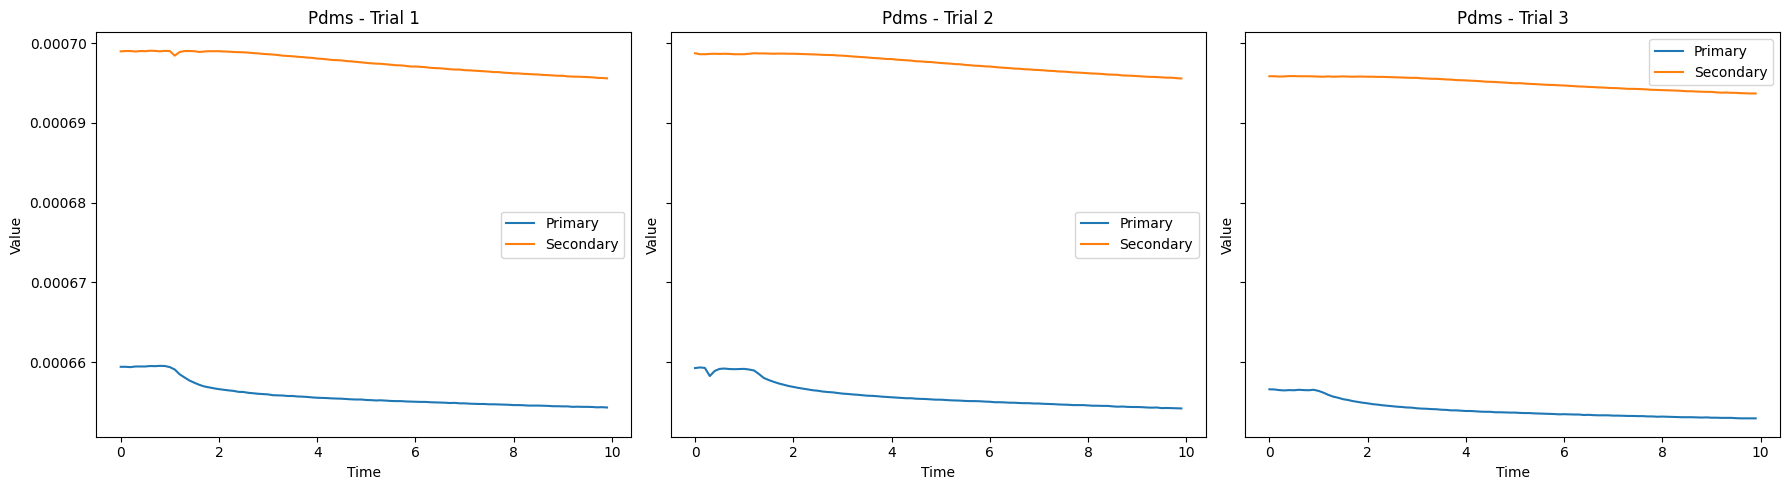

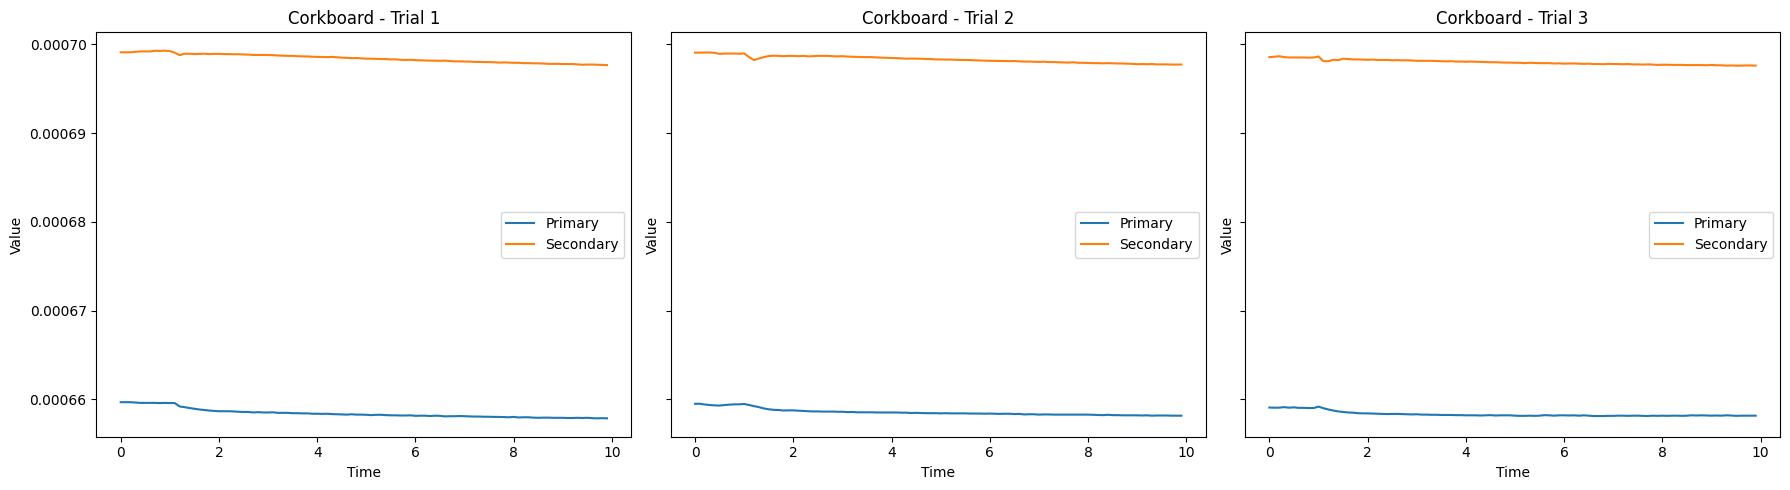

In [58]:
data = data[data['filter']]
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Manual Extraction

In [151]:
def _linear_slope_through_origin(x, y):
    """Slope of y ~ m*x through origin, robust to small denominators."""
    denom = np.sum(x * x)
    return np.sum(x * y) / denom if denom != 0 else np.nan


def forced_slope_from_elbow(time_aligned, signal_change, slope_window=1.0):
    # prefer first positive window, fallback to first N points
    mask = (time_aligned >= 0) & (time_aligned <= slope_window)
    if mask.sum() < 3:
        mask = np.arange(len(time_aligned)) < min(5, len(time_aligned))
    return _linear_slope_through_origin(time_aligned[mask], signal_change[mask])


def auc_in_window(time_aligned, signal_abs_change, window):
    mask = (time_aligned >= 0) & (time_aligned <= window)
    return np.trapz(signal_abs_change[mask], time_aligned[mask]) if mask.sum() >= 2 else np.nan


def slope_in_window(time_aligned, signal_change, window):
    mask = (time_aligned >= 0) & (time_aligned <= window)
    return _linear_slope_through_origin(time_aligned[mask], signal_change[mask]) if mask.sum() >= 3 else np.nan


def time_to_percent(time_aligned, signal_abs_change, percent):
    peak = np.nanmax(signal_abs_change)
    if peak == 0 or np.isnan(peak):
        return np.nan
    idx = np.where(signal_abs_change >= percent * peak)[0]
    return time_aligned[idx[0]] if idx.size > 0 else np.nan


def derivative_features(time_aligned, signal_change):
    if len(time_aligned) < 3 or len(np.unique(time_aligned)) < 3:
        return {
            "mean_derivative_0_1s": np.nan,
            "mean_derivative_0_2s": np.nan,
            "mean_derivative_0_5s": np.nan,
            "max_derivative": np.nan,
            "time_of_max_derivative": np.nan,
        }

    deriv = np.gradient(signal_change, time_aligned)
    max_idx = np.nanargmax(np.abs(deriv))
    out = {
        "max_derivative": deriv[max_idx],
        "time_of_max_derivative": time_aligned[max_idx],
    }
    for w in (1.0, 2.0, 5.0):
        mask = (time_aligned >= 0) & (time_aligned <= w)
        key = f"mean_derivative_0_{int(w)}s"
        out[key] = np.nanmean(deriv[mask]) if mask.sum() >= 2 else np.nan
    return out


def decay_slope_after_peak(time_aligned, signal_change, peak_time):
    mask = time_aligned >= peak_time
    if mask.sum() < 2:
        return np.nan
    x, y = time_aligned[mask], signal_change[mask]
    return (y[-1] - y[0]) / (x[-1] - x[0]) if x[-1] != x[0] else np.nan


def extract_trial_features(trial_data, slope_window=1.0):
    trial_data = trial_data.sort_values("Time", kind="stable").copy()
    time = trial_data["Time"].values
    primary = trial_data["Primary"].values
    secondary = trial_data["Secondary"].values
    difference = primary - secondary

    elbow_time = time[0]
    time_aligned = time - elbow_time

    signals = {"primary": primary, "secondary": secondary, "difference": difference}
    changes = {k: v - v[0] for k, v in signals.items()}
    abs_changes = {k: np.abs(v) for k, v in changes.items()}

    def compute_signal_features(name, change, abs_change):
        out = {}
        out[f"{name}_slope"] = forced_slope_from_elbow(time_aligned, change, slope_window)
        out[f"{name}_peak_change"] = np.nanmax(abs_change)
        peak_idx = int(np.nanargmax(abs_change)) if not np.all(np.isnan(abs_change)) else 0
        out[f"{name}_peak_time"] = time_aligned[peak_idx]
        out[f"{name}_auc"] = np.trapz(abs_change, time_aligned)

        for w in (0.5, 1.0, 2.0, 5.0):
            out[f"{name}_auc_0_{w}s"] = auc_in_window(time_aligned, abs_change, w)
            out[f"{name}_slope_0_{w}s"] = slope_in_window(time_aligned, change, w)

        for p in (10, 25, 50, 75, 90):
            out[f"{name}_time_to_{p}"] = time_to_percent(time_aligned, abs_change, p / 100.0)

        deriv = derivative_features(time_aligned, change)
        for k, v in deriv.items():
            out[f"{name}_{k}"] = v

        out[f"{name}_decay_slope"] = decay_slope_after_peak(time_aligned, change, out[f"{name}_peak_time"])
        out[f"{name}_final_offset"] = change[-1]
        return out

    result = {}
    result.update({f"{k}_elbow_value": v[0] for k, v in signals.items()})
    result["elbow_time"] = elbow_time

    for name in signals:
        result.update(compute_signal_features(name, changes[name], abs_changes[name]))

    # Ratios numerator / denominator with clear names
    for numerator, denominator in (("secondary", "primary"), ("difference", "primary")):
        result[f"{numerator}_peak_ratio"] = (
            result[f"{numerator}_peak_change"] / result[f"{denominator}_peak_change"]
            if result[f"{denominator}_peak_change"] != 0 else np.nan
        )
        result[f"{numerator}_auc_ratio"] = (
            result[f"{numerator}_auc"] / result[f"{denominator}_auc"]
            if result[f"{denominator}_auc"] != 0 else np.nan
        )
        result[f"{numerator}_slope_ratio"] = (
            result[f"{numerator}_slope"] / result[f"{denominator}_slope"]
            if result[f"{denominator}_slope"] != 0 else np.nan
        )

    result["max_derivative_ratio"] = (
        result["secondary_max_derivative"] / result["primary_max_derivative"]
        if result["primary_max_derivative"] != 0 else np.nan
    )
    result["difference_max_derivative_ratio"] = (
        result["difference_max_derivative"] / result["primary_max_derivative"]
        if result["primary_max_derivative"] != 0 else np.nan
    )

    for name in ("primary", "secondary", "difference"):
        if result.get(f"{name}_auc", 0) != 0:
            # keep key name consistent with existing style
            result[f"early_auc_ratio_{name}_0_1s"] = result.get(f"{name}_auc_0_1.0s", np.nan) / result[f"{name}_auc"]

    result["lag"] = result["secondary_peak_time"] - result["primary_peak_time"]
    for name in ("primary", "secondary", "difference"):
        result[f"{name}_rise_time_10_90"] = result.get(f"{name}_time_to_90", np.nan) - result.get(f"{name}_time_to_10", np.nan)
        result[f"{name}_rise_time_25_75"] = result.get(f"{name}_time_to_75", np.nan) - result.get(f"{name}_time_to_25", np.nan)

    result["difference_lag_from_primary"] = result["difference_peak_time"] - result["primary_peak_time"]
    result["difference_lag_from_secondary"] = result["difference_peak_time"] - result["secondary_peak_time"]

    return pd.Series(result)


In [81]:
features_df = (
    data
    .groupby(["Sample", "Trial"])
    .apply(extract_trial_features)
    .reset_index()
)

features_df

,Sample,Trial,primary_elbow_value,secondary_elbow_value,difference_elbow_value,elbow_time,primary_slope,primary_peak_change,primary_peak_time,primary_auc,...,early_auc_ratio_difference_0_1s,lag,primary_rise_time_10_90,primary_rise_time_25_75,secondary_rise_time_10_90,secondary_rise_time_25_75,difference_rise_time_10_90,difference_rise_time_25_75,difference_lag_from_primary,difference_lag_from_secondary
0,aluminum,1.0,0.000660,0.000699,-0.000039,0.00939,-2.220582e-07,0.000012,14.39131,0.000127,...,0.001166,0.30000,4.10004,1.20000,7.59996,4.40004,0.89996,0.30000,-9.60004,-9.90004
1,aluminum,2.0,0.000658,0.000697,-0.000039,0.00937,1.236585e-07,0.000010,14.29129,0.000106,...,0.002972,0.10000,4.40004,1.29996,7.90000,4.50000,0.80004,0.39996,-10.10000,-10.20000
2,aluminum,3.0,0.000659,0.000698,-0.000039,0.00932,-8.734123e-08,0.000011,16.79134,0.000112,...,0.000419,0.20000,3.40000,0.99996,7.40000,4.20000,0.69996,0.40000,-9.10000,-9.30000
3,corkboard,1.0,0.000660,0.000699,-0.000039,0.00934,4.976373e-07,0.000003,32.69136,0.000055,...,0.017746,0.40000,23.20004,8.40004,19.50000,10.40000,9.10004,8.80000,-23.00000,-23.40000
4,corkboard,2.0,0.000660,0.000699,-0.000040,0.00926,-3.428207e-07,0.000002,15.99144,0.000018,...,0.043939,0.19996,12.30000,6.20004,13.69996,9.40004,4.79996,4.49996,-11.10004,-11.30000
5,corkboard,3.0,0.000660,0.000699,-0.000040,0.00931,1.569951e-07,0.000001,17.99135,0.000018,...,0.076526,0.40000,7.80000,2.30000,15.30000,7.90001,1.69995,0.59995,-12.30000,-12.70000
6,glass,1.0,0.000660,0.000699,-0.000039,0.00938,-7.155324e-08,0.000011,22.39133,0.000116,...,0.000432,0.10000,5.50000,1.10000,9.89996,4.70004,0.80000,0.20000,-10.60004,-10.70004
7,glass,2.0,0.000660,0.000700,-0.000040,0.00924,-1.236688e-07,0.000011,21.79146,0.000108,...,0.001454,0.00000,5.20000,1.00000,8.19996,4.49996,0.59996,0.29996,-10.00000,-10.00000
8,glass,3.0,0.000660,0.000699,-0.000039,0.00936,-1.957212e-07,0.000010,22.69134,0.000113,...,0.001047,0.20000,11.70004,7.59996,8.50000,4.69996,7.60004,6.80000,-10.00004,-10.20004
9,pdms,1.0,0.000660,0.000699,-0.000040,0.00933,-3.195241e-07,0.000006,14.49133,0.000057,...,0.003332,0.10000,7.69996,3.40001,10.09996,5.10000,0.89997,0.50000,-9.89996,-9.99996


In [61]:
features = [
'primary_slope',
       'primary_peak_change', 'secondary_slope', 'secondary_peak_change',
       'peak_ratio', 'lag', 'primary_auc', 'secondary_auc', 'auc_ratio'
]

legend_col = 'Sample'

features_df = features_df[features_df['Sample'] != 'steel']

KeyError: 'peak_ratio'

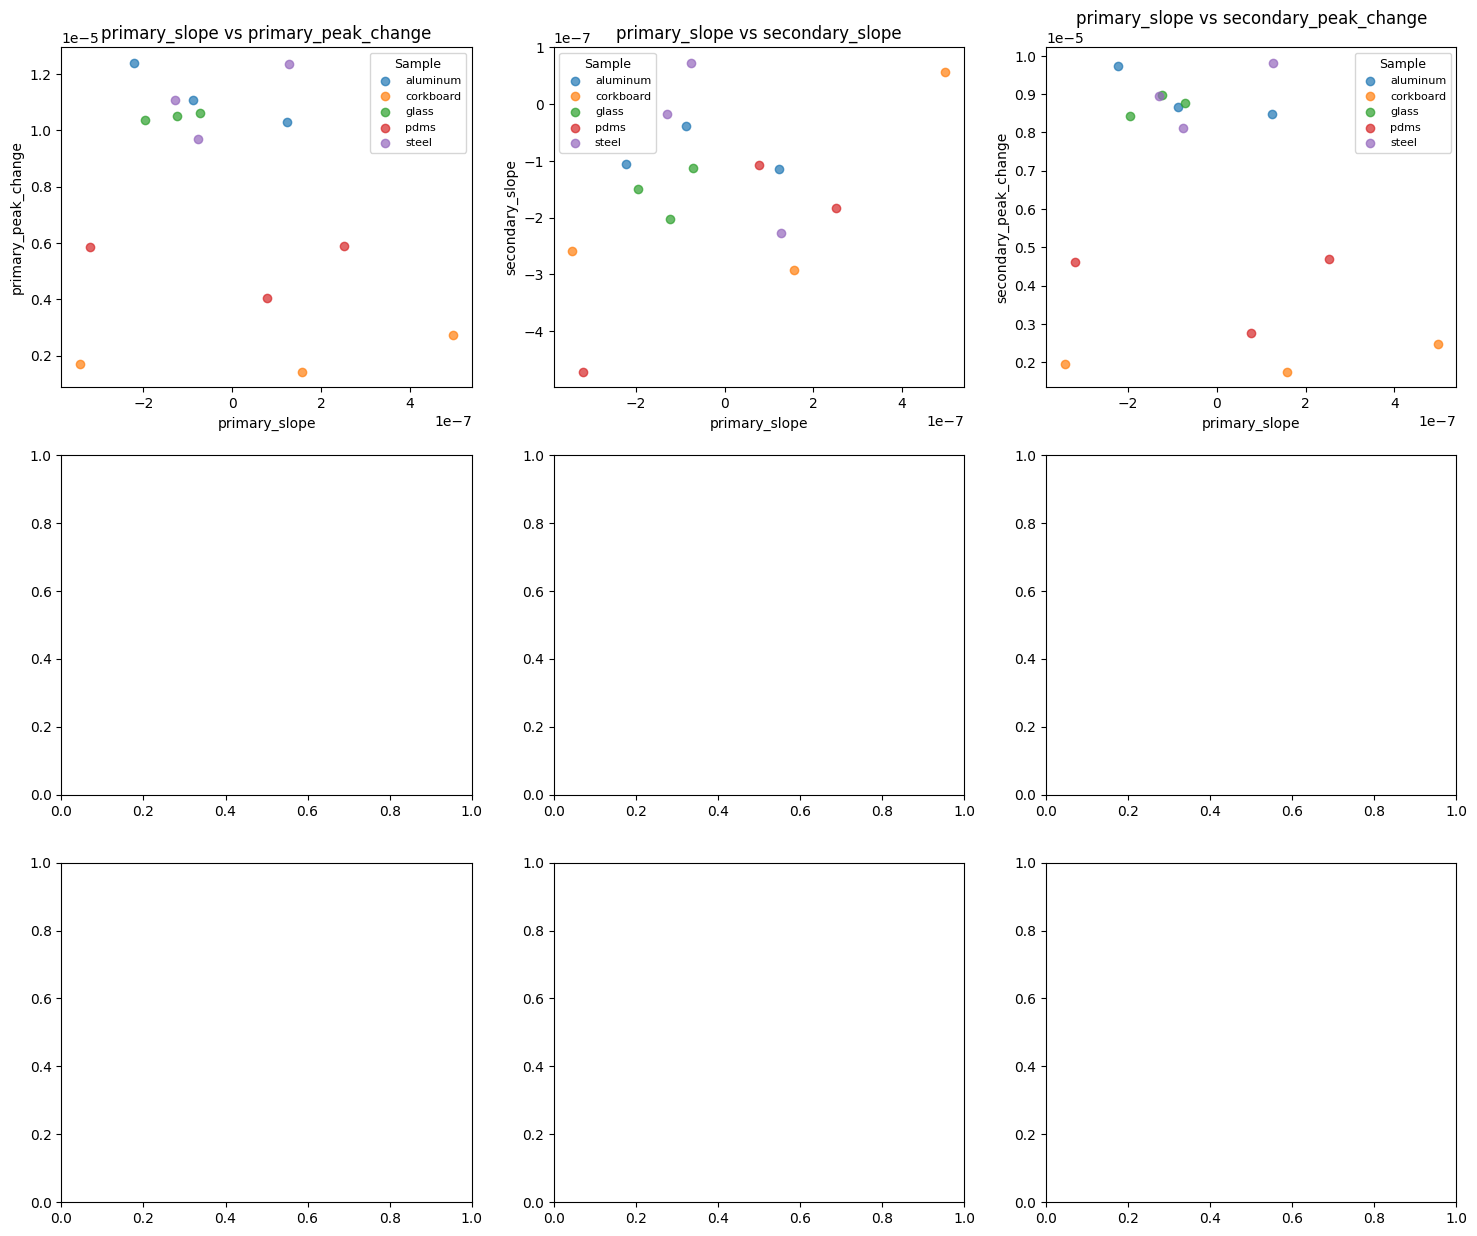

In [152]:
pairs = list(itertools.combinations(features, 2))

plots_per_fig = 9
n_cols = 3
n_rows = 3

for fig_num in range(math.ceil(len(pairs) / plots_per_fig)):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig
    current_pairs = pairs[start:end]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 15))
    axes = axes.flatten()

    for ax, (x_col, y_col) in zip(axes, current_pairs):

        for group, subset in features_df.groupby(legend_col):
            ax.scatter(
                subset[x_col],
                subset[y_col],
                label=group,
                alpha=0.7
            )

        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f'{x_col} vs {y_col}')

        ax.legend(
            title=legend_col,
            fontsize=8,
            title_fontsize=9,
            loc='best'
        )

    # hide unused subplots in the last figure
    for ax in axes[len(current_pairs):]:
        ax.axis('off')

    fig.suptitle(f'Scatter Plot Combinations - Figure {fig_num + 1}', fontsize=16)

    plt.tight_layout()
    plt.show()

In [ ]:
features_df.columns

Index(['Sample', 'Trial', 'elbow_time', 'primary_elbow_value',
       'secondary_elbow_value', 'difference_elbow_value', 'primary_slope',
       'primary_peak_change', 'secondary_slope', 'secondary_peak_change',
       'peak_ratio', 'lag', 'primary_auc', 'secondary_auc', 'auc_ratio',
       'difference_slope', 'difference_peak_change', 'difference_peak_time',
       'difference_time_to_peak', 'difference_auc', 'difference_final_offset',
       'difference_decay_slope', 'difference_peak_ratio',
       'difference_auc_ratio', 'difference_slope_ratio', 'primary_auc_0_0p5s',
       'primary_auc_0_1s', 'primary_auc_0_2s', 'primary_auc_0_5s',
       'secondary_auc_0_0p5s', 'secondary_auc_0_1s', 'secondary_auc_0_2s',
       'secondary_auc_0_5s', 'difference_auc_0_0p5s', 'difference_auc_0_1s',
       'difference_auc_0_2s', 'difference_auc_0_5s',
       'early_auc_ratio_primary_0_1s', 'early_auc_ratio_secondary_0_1s',
       'early_auc_ratio_difference_0_1s', 'primary_slope_0_0p5s',
       'pri

In [ ]:
y

array(['aluminum', 'aluminum', 'aluminum', 'corkboard', 'corkboard',
       'corkboard', 'glass', 'glass', 'glass', 'pdms', 'pdms', 'pdms'],
      dtype='<U9')

## Principal Component Analysis

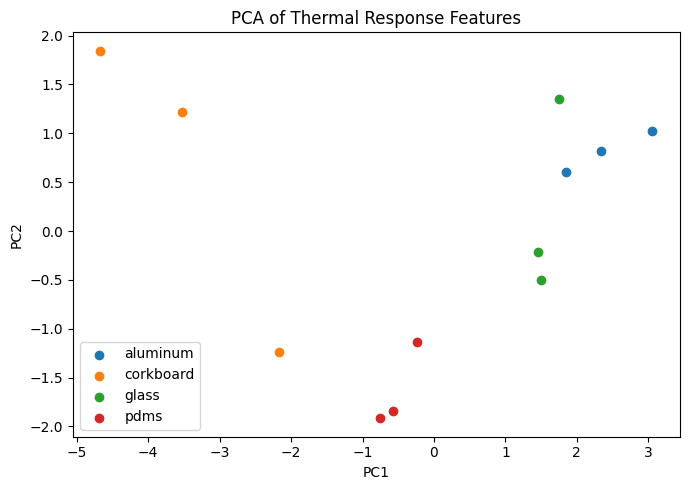

[6.07224427e-01 1.75650650e-01 1.34776157e-01 4.47613563e-02
 3.72315631e-02 2.97112663e-04 4.18341717e-05 1.66446432e-05
 2.56159726e-07]


In [ ]:
features_df = features_df.dropna(axis = 1)
X = features_df[features]
y = features_df["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

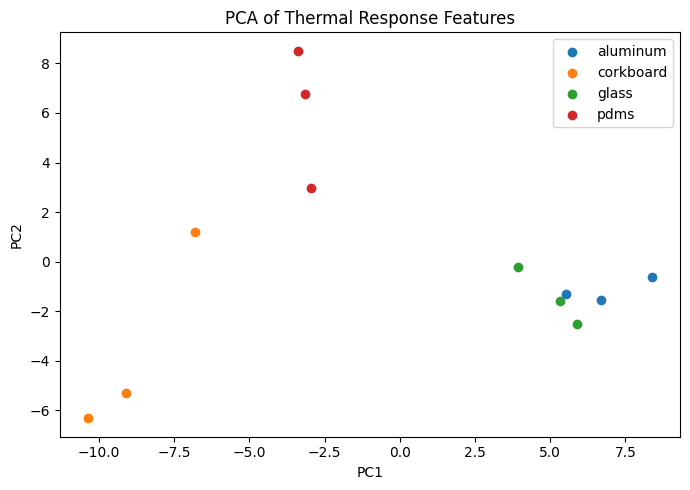

[4.59065088e-01 1.96317414e-01 1.35840732e-01 5.40039438e-02
 4.60337151e-02 3.90729320e-02 2.70869285e-02 2.11581937e-02
 1.20009204e-02 6.84830572e-03 2.57182692e-03 4.00964578e-33]


In [ ]:
features_df = features_df.dropna(axis = 1)
X = features_df[features_df.columns[6:]]
y = features_df["Sample"]


X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

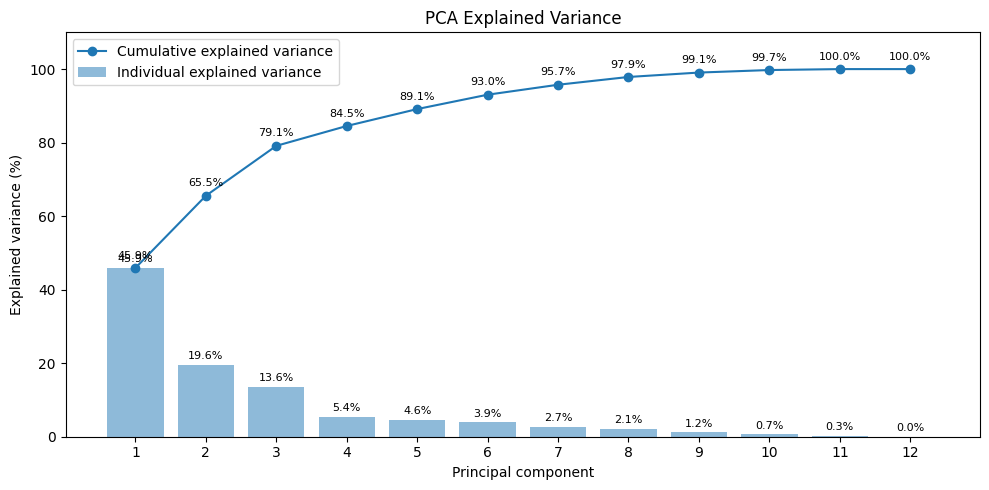

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# `tsfresh` Feature Extraction

In [ ]:
# organized tsfresh settings
_basic = [
    "mean", "median", "minimum", "maximum", "absolute_maximum"
]

_variability = [
    "standard_deviation", "variance", "root_mean_square",
    "mean_abs_change", "mean_change"
]

_distribution = ["skewness", "kurtosis"]
_energy = ["abs_energy", "sum_values"]
_counts = ["count_above_mean", "count_below_mean"]
_strikes = ["longest_strike_above_mean", "longest_strike_below_mean"]

_linear_trend = [{"attr": a} for a in ("slope", "intercept", "rvalue", "pvalue", "stderr")]
_autocorr = [{"lag": l} for l in (1, 2, 5, 10)]
_change_quantiles = [
    {"ql": 0.0, "qh": 0.2, "isabs": False, "f_agg": "mean"},
    {"ql": 0.0, "qh": 0.2, "isabs": True,  "f_agg": "mean"},
    {"ql": 0.8, "qh": 1.0, "isabs": False, "f_agg": "mean"},
    {"ql": 0.8, "qh": 1.0, "isabs": True,  "f_agg": "mean"},
]
_cid_ce = [{"normalize": True}, {"normalize": False}]

settings = {k: None for k in (_basic + _variability + _distribution + _energy + _counts + _strikes)}
settings.update({
    "linear_trend": _linear_trend,
    "autocorrelation": _autocorr,
    "change_quantiles": _change_quantiles,
    "cid_ce": _cid_ce,
})


In [156]:
# use only filtered data
ts_data = data[(data["filter"]) & (data['Sample'] != 'steel')].copy()

# create one ID per material-trial
ts_data["id"] = (
    ts_data["Sample"].astype(str) +
    "_trial_" +
    ts_data["Trial"].astype(int).astype(str)
)

# primary sensor table
primary = ts_data[[
    "id",
    "Time",
    "Primary"
]].copy()

primary = primary.rename(columns={
    "Time": "time",
    "Primary": "value"
})

primary["kind"] = "Primary"

# secondary sensor table
secondary = ts_data[[
    "id",
    "Time",
    "Secondary"
]].copy()

secondary = secondary.rename(columns={
    "Time": "time",
    "Secondary": "value"
})

secondary["kind"] = "Secondary"


# diff sensor table
diff = ts_data[[
    "id",
    "Time",
    "diff"
]].copy()

diff = diff.rename(columns={
    "Time": "time",
    "diff": "value"
})

diff["kind"] = "Difference"

# combine primary and secondary
tsfresh_input = pd.concat(
    [primary, secondary, diff],
    ignore_index=True
)

tsfresh_input = tsfresh_input[[
    "id",
    "time",
    "kind",
    "value"
]]

# clean invalid values
tsfresh_input = tsfresh_input.replace([np.inf, -np.inf], np.nan)
tsfresh_input = tsfresh_input.dropna()

tsfresh_input.head()

KeyError: 'filter'

In [ ]:
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    default_fc_parameters=settings,
    n_jobs=0
)

Feature Extraction: 100%|██████████| 36/36 [00:00<00:00, 563.67it/s]


In [ ]:
labels = (
    ts_data[["id", "Sample", "Trial"]]
    .drop_duplicates()
    .set_index("id")
)
tsfresh_features = tsfresh_features.dropna(axis=1)


tsfresh_features = tsfresh_features.join(labels)
tsfresh_features = tsfresh_features.reset_index()
tsfresh_features.head()

,index,Difference__mean,Difference__median,Difference__minimum,Difference__maximum,Difference__absolute_maximum,Difference__standard_deviation,Difference__variance,Difference__root_mean_square,Difference__mean_abs_change,...,"Secondary__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.8","Secondary__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Secondary__count_above_mean,Secondary__count_below_mean,Secondary__longest_strike_above_mean,Secondary__longest_strike_below_mean,Secondary__cid_ce__normalize_True,Secondary__cid_ce__normalize_False,Sample,Trial
0,aluminum_trial_1,0.000045,0.000045,0.000040,0.000048,0.000048,2.433164e-06,5.920287e-12,0.000045,1.422222e-07,...,-1.368421e-08,3.894737e-08,49.0,51.0,49.0,51.0,0.338526,1.006380e-06,aluminum,1.0
1,aluminum_trial_2,0.000044,0.000044,0.000039,0.000046,0.000046,2.055193e-06,4.223819e-12,0.000044,1.210101e-07,...,-1.789474e-08,5.157895e-08,49.0,51.0,49.0,51.0,0.356671,9.057593e-07,aluminum,2.0
2,aluminum_trial_3,0.000044,0.000044,0.000039,0.000047,0.000047,2.239798e-06,5.016696e-12,0.000044,1.337374e-07,...,-1.684211e-08,5.052632e-08,49.0,51.0,49.0,51.0,0.354024,9.459387e-07,aluminum,3.0
3,corkboard_trial_1,0.000040,0.000040,0.000039,0.000040,0.000040,2.209865e-07,4.883504e-14,0.000040,3.212121e-08,...,-4.000000e-09,3.000000e-08,49.0,51.0,49.0,51.0,0.944553,4.481071e-07,corkboard,1.0
4,corkboard_trial_2,0.000040,0.000040,0.000039,0.000040,0.000040,1.976359e-07,3.905996e-14,0.000040,3.636364e-08,...,-4.000000e-09,2.266667e-08,48.0,52.0,36.0,51.0,1.693661,6.606058e-07,corkboard,2.0


## Principal Component Analysis

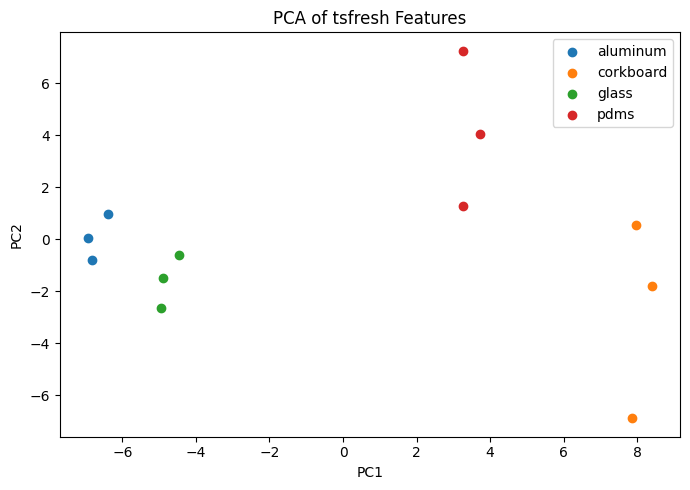

[6.24228913e-01 1.90515315e-01 1.10125101e-01 2.70733766e-02
 1.99922443e-02 1.16100686e-02 7.33975708e-03 4.16027218e-03
 2.40221082e-03 1.43985209e-03 1.11288870e-03 8.52207597e-33]


In [ ]:
feature_cols = tsfresh_features.drop(columns=["index", "Sample", "Trial"]).columns
feature_cols = [c for c in feature_cols if 'Difference' not in c]

X = tsfresh_features[feature_cols]
y = tsfresh_features["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in y.unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of tsfresh Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

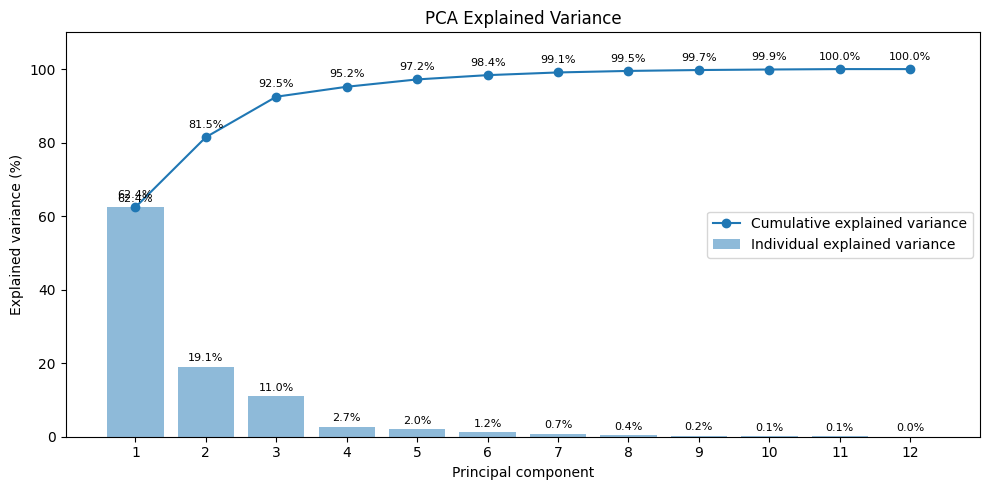

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# Reservoir Computing

In [ ]:
rc_data = data[(data["filter"]) & (data['Sample'] != 'steel')].copy()
rc_data = rc_data.sort_values(["Sample", "Trial", "Time"])

length_check = (
    rc_data
    .groupby(["Sample", "Trial"])
    .size()
    .reset_index(name="n_points")
)

min_len = length_check["n_points"].min()

X_list = []
y_list = []

for (sample, trial), subset in rc_data.groupby(["Sample", "Trial"]):

    subset = subset.sort_values("Time").head(min_len)

    sequence = subset[[
        "Primary",
        "Secondary"
    ]].values

    X_list.append(sequence)
    y_list.append(sample)

X = X_list
y = np.array(y_list)

print(len(X))
print(X[0].shape)
print(y.shape)


le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)
print(y_encoded)

12
(100, 2)
(12,)
['aluminum' 'corkboard' 'glass' 'pdms']
[0 0 0 1 1 1 2 2 2 3 3 3]


In [ ]:
X_rc = []

for sequence in X:

    reservoir = Reservoir(
        units=50,
        sr=0.9,
        lr=0.3,
        input_scaling=0.5,
        seed=42
    )

    states = reservoir.run(sequence)

    features = np.concatenate([
        states.mean(axis=0),
        states.std(axis=0),
        states[-1, :]
    ])

    X_rc.append(features)

X_rc = np.array(X_rc)

print(X_rc.shape)

(12, 150)


## Principal Component Analysis

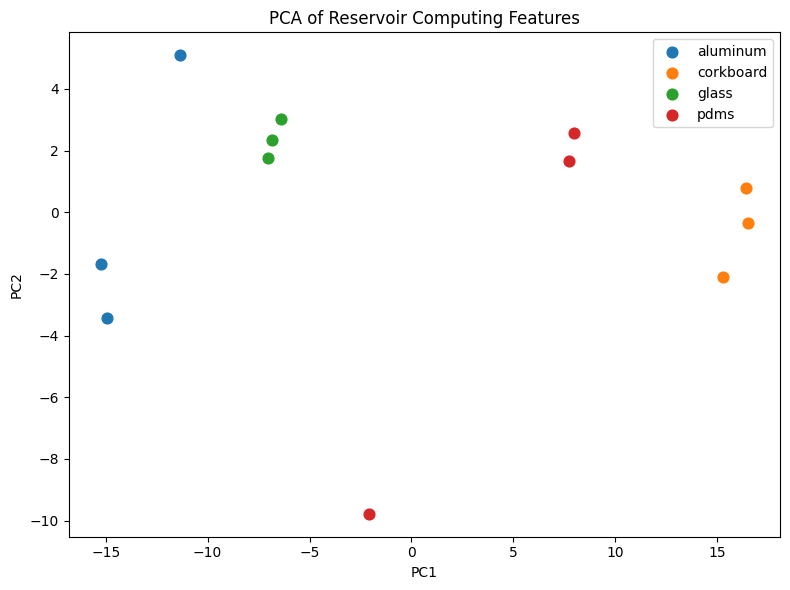

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rc)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

materials = np.unique(y)

plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Reservoir Computing Features")
plt.legend()
plt.tight_layout()
plt.show()

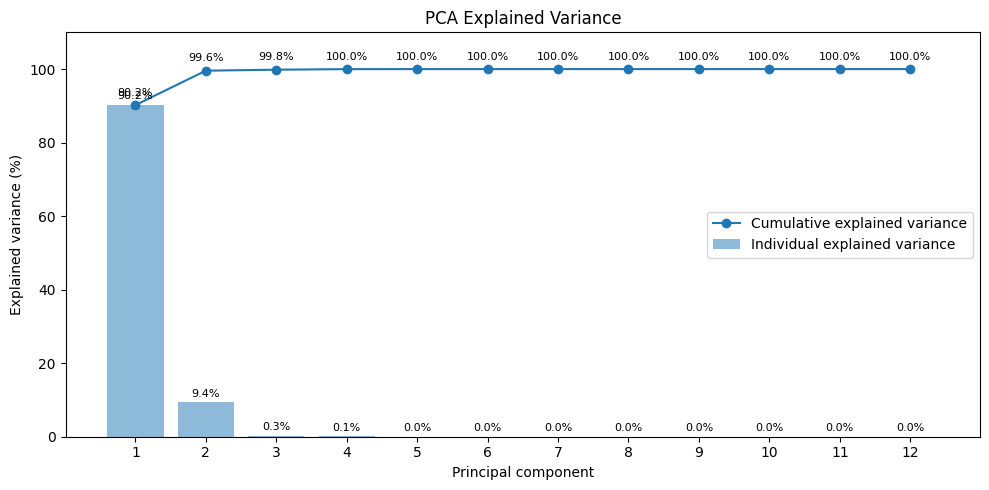

In [ ]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()